In [175]:
from pathlib import Path
import glob

diretorio = Path('.')

total_bytes = 0

print(f"{'Nome do Arquivo':<50} | {'Tamanho':<10}")
print("-" * 65)

for arquivo in diretorio.glob("*.parquet"):
    tamanho_bytes = arquivo.stat().st_size
    total_bytes += tamanho_bytes
    tamanho_mb = tamanho_bytes / (1024 * 1024)
    print(f"{arquivo.name:<50} | {tamanho_mb:.2f} MB")

total_gb = total_bytes / (1024 * 1024 * 1024)

print("-" * 65)
print(f"Total de arquivos .parquet: {total_gb:.2f} GB")

Nome do Arquivo                                    | Tamanho   
-----------------------------------------------------------------
fhvhv_tripdata_2025-01.parquet                     | 468.33 MB
fhvhv_tripdata_2025-02.parquet                     | 440.25 MB
fhvhv_tripdata_2025-03.parquet                     | 478.54 MB
fhvhv_tripdata_2025-04.parquet                     | 464.65 MB
fhvhv_tripdata_2025-05.parquet                     | 493.42 MB
fhvhv_tripdata_2025-06.parquet                     | 468.08 MB
fhvhv_tripdata_2025-07.parquet                     | 464.65 MB
fhvhv_tripdata_2025-08.parquet                     | 457.36 MB
fhvhv_tripdata_2025-09.parquet                     | 458.58 MB
fhvhv_tripdata_2025-10.parquet                     | 494.47 MB
fhvhv_tripdata_2025-11.parquet                     | 483.98 MB
fhvhv_tripdata_2025-12.parquet                     | 510.94 MB
fhvhv_tripdata_2026-01.parquet                     | 482.43 MB
fhvhv_tripdata_2026-02.parquet                     

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import duckdb as db

con = db.connect('nyc_tlc_data_record')
con.sql("SET memory_limit = '8GB';")

---

### Dicionário das localidades de Nova York

In [106]:
con.sql("""
CREATE OR REPLACE VIEW zonas_taxi AS SELECT * FROM read_csv('C:/Users/mayma/Documents/Projetos/NYC_TLC_Database/taxi_zone_lookup (1).csv'); 
""")

In [182]:
zonas_taxi = con.sql("""
SELECT * FROM zonas_taxi; 
""").df()

zonas_taxi

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,N/A,N/A


In [183]:
dicio_chegada = zonas_taxi.rename(columns={'LocationID': 'PULocationID'})
dicio_chegada = dicio_chegada.drop(columns='service_zone')

dicio_destino = zonas_taxi.rename(columns={'LocationID': 'DOLocationID'})
dicio_destino = dicio_destino.drop(columns='service_zone')

dicio_destino

,DOLocationID,Borough,Zone
0,1,EWR,Newark Airport
1,2,Queens,Jamaica Bay
2,3,Bronx,Allerton/Pelham Gardens
3,4,Manhattan,Alphabet City
4,5,Staten Island,Arden Heights
...,...,...,...
260,261,Manhattan,World Trade Center
261,262,Manhattan,Yorkville East
262,263,Manhattan,Yorkville West
263,264,Unknown,N/A


---

# Dados Yellow Taxi Trip Records 

In [94]:
con.sql("""
SELECT * FROM yellow_2025 LIMIT 10
""")

┌──────────┬──────────────────────┬───────────────────────┬─────────────────┬───────────────┬────────────┬────────────────────┬──────────────┬──────────────┬──────────────┬─────────────┬────────┬─────────┬────────────┬──────────────┬───────────────────────┬──────────────┬──────────────────────┬─────────────┬────────────────────┐
│ VendorID │ tpep_pickup_datetime │ tpep_dropoff_datetime │ passenger_count │ trip_distance │ RatecodeID │ store_and_fwd_flag │ PULocationID │ DOLocationID │ payment_type │ fare_amount │ extra  │ mta_tax │ tip_amount │ tolls_amount │ improvement_surcharge │ total_amount │ congestion_surcharge │ Airport_fee │ cbd_congestion_fee │
│  int32   │      timestamp       │       timestamp       │      int64      │    double     │   int64    │      varchar       │    int32     │    int32     │    int64     │   double    │ double │ double  │   double   │    double    │        double         │    double    │        double        │   double    │       double       │
├──────

In [169]:
con.sql("""
SELECT COUNT(*) AS linhas_yellow25 FROM yellow_2025
""")

┌─────────────────┐
│ linhas_yellow25 │
│      int64      │
├─────────────────┤
│        48721806 │
└─────────────────┘

In [164]:
con.sql("""
DESCRIBE SELECT * FROM yellow_2025
""")

┌───────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name      │ column_type │  null   │   key   │ default │  extra  │
│        varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ VendorID              │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_pickup_datetime  │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_dropoff_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ passenger_count       │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ trip_distance         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ RatecodeID            │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ store_and_fwd_flag    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ PULocationID          │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ DOLocationID          │ INTEGER     │ 

In [165]:
con.sql("""
SUMMARIZE yellow_2025
""")

┌───────────────────────┬─────────────┬─────────────────────┬─────────────────────┬───────────────┬────────────────────────────┬─────────────────────┬────────────────────────────┬────────────────────────────┬────────────────────────────┬──────────┬─────────────────┐
│      column_name      │ column_type │         min         │         max         │ approx_unique │            avg             │         std         │            q25             │            q50             │            q75             │  count   │ null_percentage │
│        varchar        │   varchar   │       varchar       │       varchar       │     int64     │          varchar           │       varchar       │          varchar           │          varchar           │          varchar           │  int64   │  decimal(9,2)   │
├───────────────────────┼─────────────┼─────────────────────┼─────────────────────┼───────────────┼────────────────────────────┼─────────────────────┼────────────────────────────┼────────────────────

In [37]:
prejuizo = con.sql("""
SELECT SUM(total_amount) AS Viagens_comprometidas FROM yellow_2025 WHERE total_amount > 0;
""").df()

prejuizo

,Viagens_comprometidas
0,1.335842e+09


In [32]:
con.sql("""
SELECT COUNT(*) AS Viagens_comprometidas FROM yellow_2025 WHERE total_amount < 0;
""")


┌───────────────────────┐
│ Viagens_comprometidas │
│         int64         │
├───────────────────────┤
│                973706 │
└───────────────────────┘

In [39]:
Media_tarifa = con.sql("""
SELECT
    AVG(fare_amount) AS tarifa_media
FROM yellow_2025;
""").df()

Media_tarifa

,tarifa_media
0,18.419146


In [9]:
df_pagamentos = con.sql("""
SELECT 
    CASE 
        WHEN payment_type = 0 THEN 'Flex Fare'
        WHEN payment_type = 1 THEN 'Credit Card'
        WHEN payment_type = 2 THEN 'Cash'
        WHEN payment_type = 3 THEN 'No Charge'
        WHEN payment_type = 4 THEN 'Dispute'
        WHEN payment_type = 5 THEN 'Unknown'
        WHEN payment_type = 6 THEN 'Voided'
        ELSE 'Other'
    END AS tipo_pagamento,
    COUNT(*) AS contagem
FROM yellow_2025
GROUP BY payment_type
ORDER BY contagem DESC;
""").df()

df_pagamentos

,tipo_pagamento,contagem
0,Credit Card,31053606
1,Flex Fare,11611615
2,Cash,4654242
3,Dispute,1094195
4,No Charge,308145
5,Unknown,3


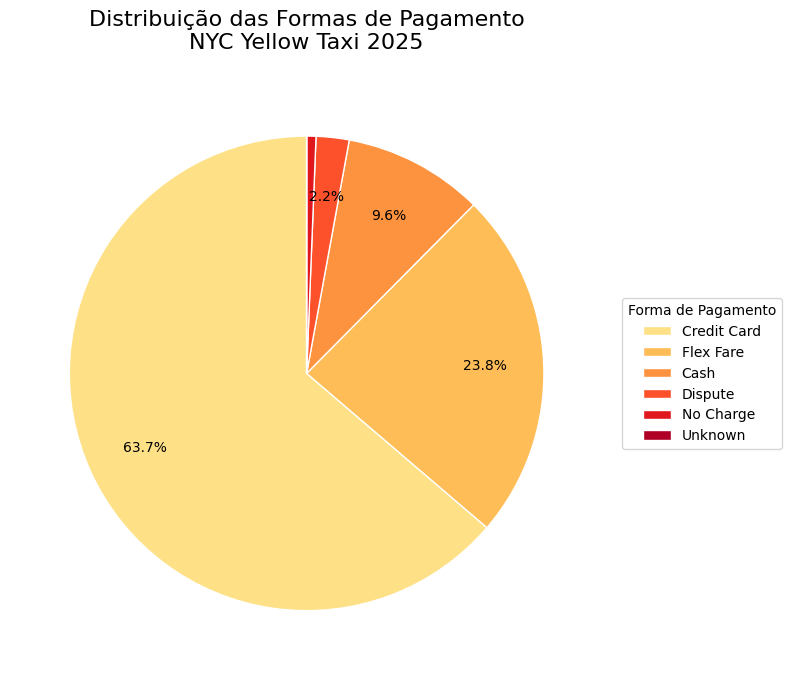

In [ ]:
colors = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(df_pagamentos)))

fig, ax = plt.subplots(figsize=(8, 8))

def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

wedges, texts, autotexts = ax.pie(
    df_pagamentos["contagem"],
    autopct=autopct_format,
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

ax.legend(
    wedges,
    df_pagamentos["tipo_pagamento"],
    title="Forma de Pagamento",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_title(
    "Distribuição das Formas de Pagamento\nNYC Yellow Taxi 2025",
    fontsize=16,
    pad=20
)

plt.tight_layout()
plt.show()

In [189]:
rotas_yellow2025 = con.sql("""
SELECT PULocationID, DOLocationID, COUNT(*) AS taxis_amarelos_tomados, 
       AVG(fare_amount) AS tarifa_media, AVG(trip_distance) AS distancia_media FROM yellow_2025
GROUP BY PULocationID, DOLocationID ORDER BY taxis_amarelos_tomados DESC LIMIT 15;
""").df()

rotas_yellow2025

,PULocationID,DOLocationID,taxis_amarelos_tomados,tarifa_media,distancia_media
0,237,236,302261,8.609484,1.878496
1,236,237,259469,9.048902,1.689527
2,237,237,215714,7.314235,0.627787
3,236,236,197782,6.822433,0.585384
4,161,237,143046,10.210182,2.087047
5,237,161,133752,10.392609,2.012434
6,161,236,115424,14.090605,2.842293
7,132,132,108207,31.224123,1.272082
8,237,162,107295,9.391253,1.188811
9,142,239,105422,7.811399,0.971941


In [190]:
rotas_yellow2025 = rotas_yellow2025.merge(dicio_chegada, on='PULocationID', how='left')

rotas_yellow2025.rename(columns={'Borough': 'bairro_partida', 'Zone': 'Zona_partida'}, inplace=True)

colunas_sem_partida = [col for col in rotas_yellow2025.columns if col not in ['bairro_partida', 'Zona_partida']]
nova_ordem_partida = ['bairro_partida', 'Zona_partida'] + colunas_sem_partida
rotas_yellow2025 = rotas_yellow2025[nova_ordem_partida]

rotas_yellow2025 = rotas_yellow2025.merge(dicio_destino, on='DOLocationID', how='left')

rotas_yellow2025.rename(columns={'Borough': 'bairro_destino', 'Zone': 'Zona_destino'}, inplace=True)

colunas_restantes = [col for col in rotas_yellow2025.columns if col not in ['bairro_partida', 'Zona_partida', 'bairro_destino', 'Zona_destino']]
nova_ordem_final = ['bairro_partida', 'Zona_partida', 'bairro_destino', 'Zona_destino'] + colunas_restantes
rotas_yellow2025 = rotas_yellow2025[nova_ordem_final]

rotas_yellow2025.drop(columns = ['PULocationID', 'DOLocationID'])

,bairro_partida,Zona_partida,bairro_destino,Zona_destino,taxis_amarelos_tomados,tarifa_media,distancia_media
0,Manhattan,Upper East Side South,Manhattan,Upper East Side North,302261,8.609484,1.878496
1,Manhattan,Upper East Side North,Manhattan,Upper East Side South,259469,9.048902,1.689527
2,Manhattan,Upper East Side South,Manhattan,Upper East Side South,215714,7.314235,0.627787
3,Manhattan,Upper East Side North,Manhattan,Upper East Side North,197782,6.822433,0.585384
4,Manhattan,Midtown Center,Manhattan,Upper East Side South,143046,10.210182,2.087047
5,Manhattan,Upper East Side South,Manhattan,Midtown Center,133752,10.392609,2.012434
6,Manhattan,Midtown Center,Manhattan,Upper East Side North,115424,14.090605,2.842293
7,Queens,JFK Airport,Queens,JFK Airport,108207,31.224123,1.272082
8,Manhattan,Upper East Side South,Manhattan,Midtown East,107295,9.391253,1.188811
9,Manhattan,Lincoln Square East,Manhattan,Upper West Side South,105422,7.811399,0.971941


In [3]:
tarifa_media_horaria_yellow = con.sql("""
SELECT DATE_TRUNC('hour', tpep_pickup_datetime) AS hora,
       AVG(fare_amount) AS tarifa_media_horaria FROM yellow_2025
       GROUP BY DATE_TRUNC('hour', tpep_pickup_datetime) ORDER BY hora ASC;
""").df()

tarifa_media_horaria_yellow

,hora,tarifa_media_horaria
0,2024-12-31 23:00:00,29.137500
1,2025-01-01 00:00:00,16.498912
2,2025-01-01 01:00:00,16.690816
3,2025-01-01 02:00:00,15.076975
4,2025-01-01 03:00:00,11.868873
...,...,...
8755,2025-12-31 19:00:00,20.461782
8756,2025-12-31 20:00:00,22.107680
8757,2025-12-31 21:00:00,21.857346
8758,2025-12-31 22:00:00,21.954186


In [10]:
tarifa_media_horaria_yellow.loc[tarifa_media_horaria_yellow.isna().any(axis = 1)]

,hora,tarifa_media_horaria


In [4]:
tarifa_media_horaria_yellow.set_index('hora', inplace = True)

<Axes: title={'center': 'Série Temporal de Tarifa Média Horária dos Táxis Amarelos 2025'}, xlabel='hora'>

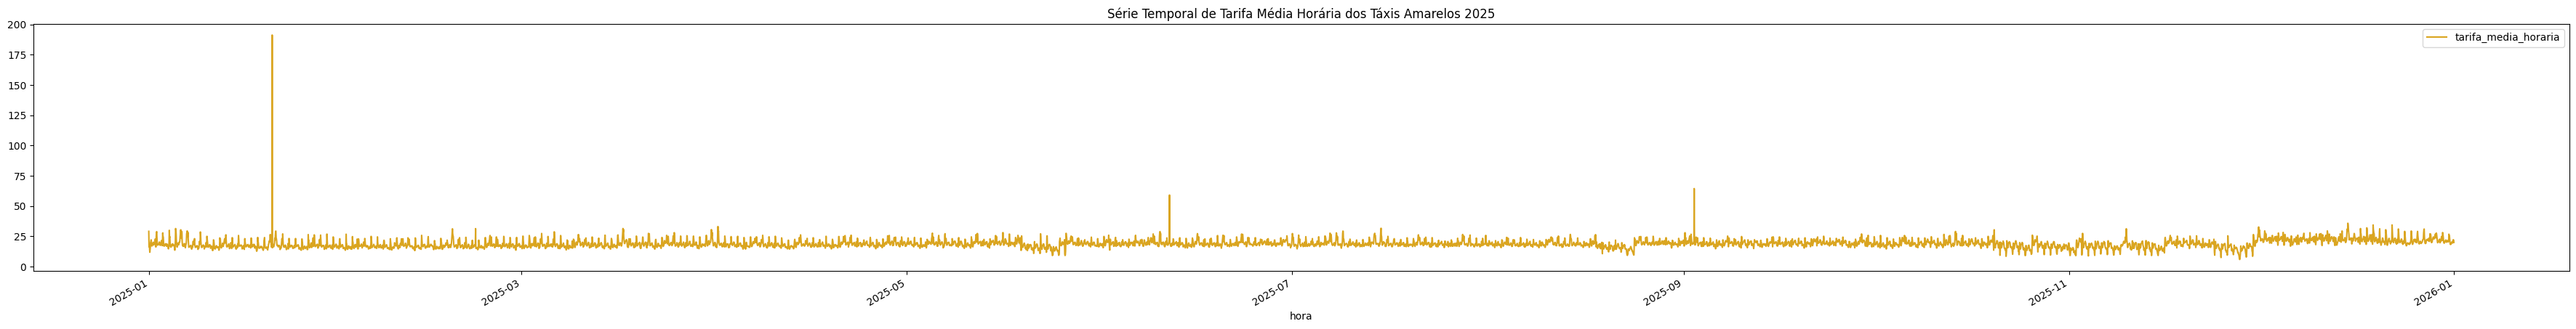

In [5]:
tarifa_media_horaria_yellow.plot(figsize = (45,5), 
                                 title = 'Série Temporal de Tarifa Média Horária dos Táxis Amarelos 2025',
                                 color = '#DAA520')

As séries temporais de yellow taxi, green taxi, e fhvhv tem relação??


## 1. Decomposição Clássica (seasonal_decompose)

A decomposição clássica é o método mais antigo e intuitivo para isolar componentes. Ela pressupõe que a série original $Y_t$ pode ser representada como uma combinação algébrica estável de três componentes: Tendência-Ciclo ($T_t$), Sazonalidade ($S_t$) e Resíduo/Irregularidade ($I_t$).

A decomposição clássica opera sob duas estruturas matemáticas principais:

Modelo Aditivo: Ideal quando a amplitude da variação sazonal permanece constante ao longo do tempo, independentemente do nível da tendência.

$$Y_t = T_t + S_t + I_t$$

Modelo Multiplicativo: Indicado quando a variação sazonal é proporcional ao nível da tendência (ou seja, se a tendência cresce, os picos sazonais também se tornam mais amplos).

$$Y_t = T_t \times S_t \times I_t$$

(Nota: O modelo multiplicativo pode ser transformado em aditivo aplicando-se o logaritmo natural na série: $\ln(Y_t) = \ln(T_t) + \ln(S_t) + \ln(I_t)$).

O algoritmo clássico utiliza médias móveis consecutivas para extrair a tendência, seguindo este pipeline:

Estimação da Tendência ($T_t$): Aplica-se uma média móvel simétrica de ordem correspondente ao período sazonal $m$ (ex: $m = 24$ para dados horários, ou $m = 7$ para dados diários). Se $m$ for par, calcula-se uma média móvel centralizada $2 \times m$-MA para evitar desalinhamento temporal:

$$T_t = \frac{1}{m} \sum_{j=-k}^{k} Y_{t+j} \quad (\text{para } m \text{ ímpar, onde } k = (m-1)/2)$$

Remoção da Tendência (Detrending): Retira-se a tendência estimada da série original. Para o modelo aditivo, faz-se $Y_t - T_t$. Para o multiplicativo, $Y_t / T_t$.

Estimação da Sazonalidade ($S_t$): Calcula-se a média dos valores resultantes da etapa 2 para cada período do ciclo (ex: a média de todas as segundas-feiras, de todas as terças-feiras, etc.). Esses índices sazonais brutos são então centralizados (para garantir que sua soma seja zero no caso aditivo, ou que sua média seja 1 no multiplicativo) e replicados para cobrir toda a extensão da série.

Cálculo do Resíduo ($I_t$): O resíduo é o que resta após remover os componentes de tendência e sazonalidade da série observada:

$$I_t = Y_t - T_t - S_t \quad (\text{aditivo})$$

$$I_t = \frac{Y_t}{T_t \times S_t} \quad (\text{multiplicativo})$$

Parâmetros na Biblioteca statsmodels: No Python, a função é executada por statsmodels.tsa.seasonal.seasonal_decompose.

```python
from statsmodels.tsa.seasonal import seasonal_decompose

resultado = seasonal_decompose(
    x=serie_tlc, 
    model='additive', 
    period=24, 
    two_sided=True, 
    extrapolate_trend='freq')
```

- x (array_like): A série temporal unidimensional.

- model (str, padrão='additive'): Define a relação estrutural entre os componentes ('additive' ou 'multiplicative').

- period (int, opcional): Período da sazonalidade (ex: 24 se os dados são agregados por hora e exibem ciclo diário; 7 para dados diários com ciclo semanal). Se a entrada for um objeto pandas.DataFrame com índice de frequência temporal explícito (ex: H para horas), o statsmodels infere o valor automaticamente.

- two_sided (bool, padrão=True): Define se a média móvel usada para estimar a tendência usará termos passados e futuros de forma simétrica. Se False, usará apenas dados passados (média móvel causal).

- extrapolate_trend (int ou str, padrão=0): Controla o preenchimento de valores ausentes ($NaNs$) nas extremidades da série, decorrentes do uso de médias móveis centralizadas. Se 'freq', o algoritmo extrapola a tendência usando regressão linear baseada nas primeiras e últimas observações válidas.

Prós: 

Altamente intuitivo, de rápida computação e ideal para diagnósticos iniciais simplificados.

Contras: 
1. Rigidez Sazonal: Pressupõe que o padrão sazonal é estritamente estático (idêntico do início ao fim da série).
2. Perda de Dados nas Borda: O uso de médias móveis centralizadas resulta em valores perdidos ($NaN$) no início e no fim do vetor da tendência, a menos que métodos de extrapolação sejam aplicados.
3. Sensibilidade a Outliers: Choques abruptos na série contaminam a estimativa da tendência de forma severa.

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

dec_sazonal = seasonal_decompose(tarifa_media_horaria_yellow, model = 'additive', filt = None, period = 24, two_sided = True, extrapolate_trend = 0)

tendencia = dec_sazonal.trend
sazonalidade = dec_sazonal.seasonal
residuo = dec_sazonal.resid

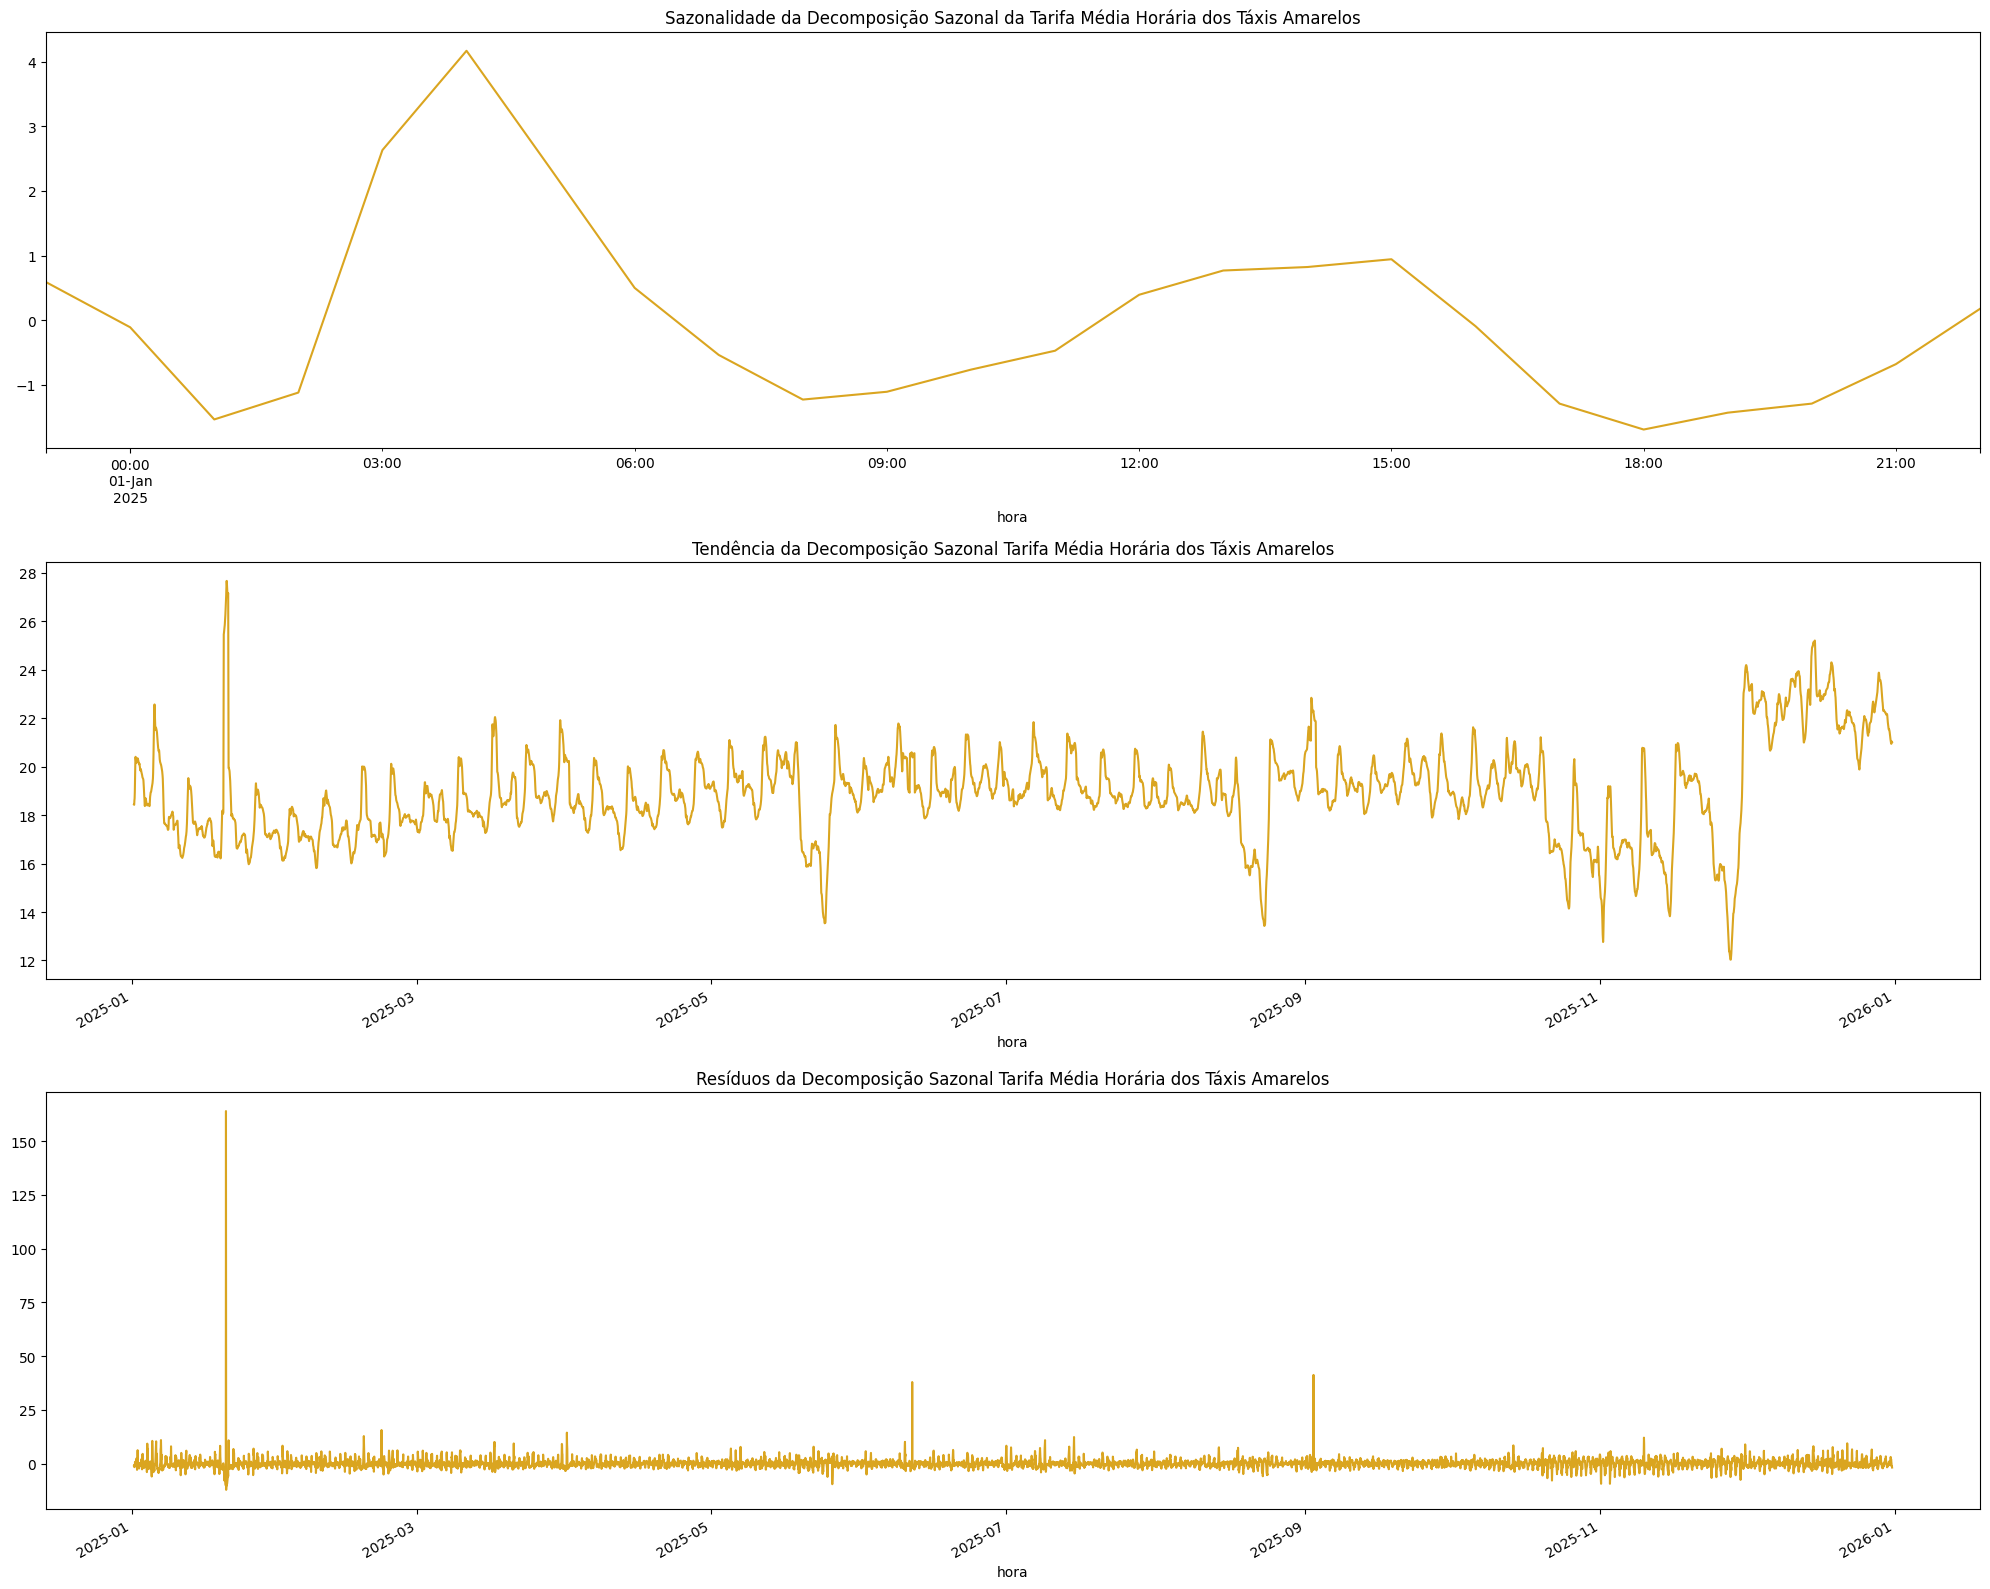

In [39]:
fig, axes = plt.subplots(3, 1, figsize = (20, 16))

sazonalidade.iloc[:24].plot(title = 'Sazonalidade da Decomposição Sazonal da Tarifa Média Horária dos Táxis Amarelos', color = '#DAA520', ax = axes[0])
tendencia.plot(title = 'Tendência da Decomposição Sazonal Tarifa Média Horária dos Táxis Amarelos', color = '#DAA520', ax = axes[1])
residuo.plot(title = 'Resíduos da Decomposição Sazonal Tarifa Média Horária dos Táxis Amarelos', color = '#DAA520', ax = axes[2])

plt.tight_layout()
plt.show()

In [45]:
print(tendencia.std())
print(tarifa_media_horaria_yellow.std())

1.88688020148577
tarifa_media_horaria    3.586528
dtype: float64


In [54]:
from scipy.signal import periodogram

freqs, power = periodogram(tarifa_media_horaria_yellow.iloc[:,0])

Text(0.5, 1.0, 'Periodograma')

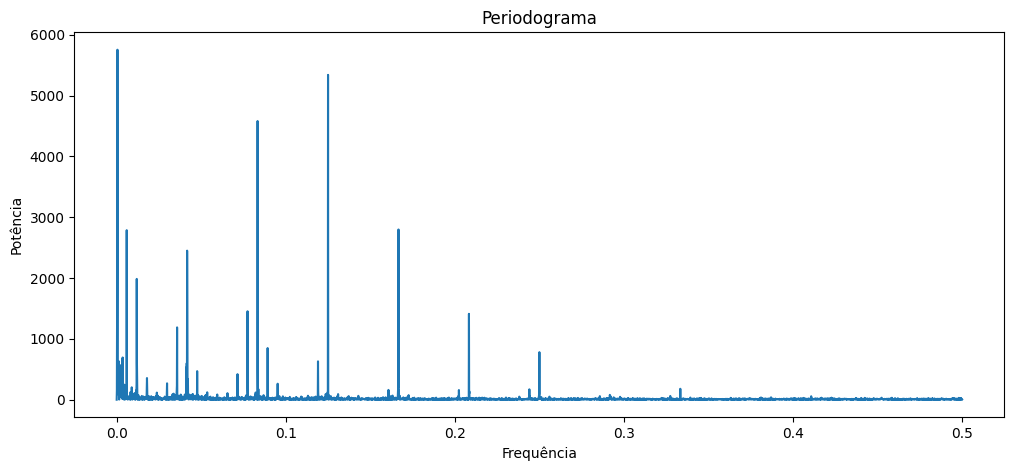

In [55]:
plt.figure(figsize=(12,5))

plt.plot(freqs, power)

plt.xlabel("Frequência")
plt.ylabel("Potência")

plt.title("Periodograma")

Text(0.5, 1.0, 'Periodograma em função do período')

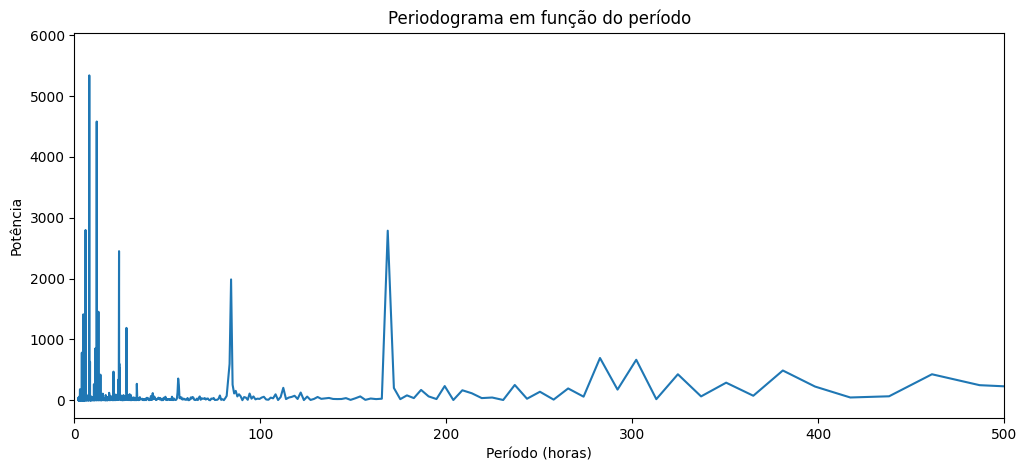

In [56]:
periodos = 1 / freqs[1:]

potencias = power[1:]

plt.figure(figsize=(12,5))

plt.plot(periodos, potencias)

plt.xlim(0,500)

plt.xlabel("Período (horas)")
plt.ylabel("Potência")

plt.title("Periodograma em função do período")

## Decomposição de Múltipla Sazonalidade: O Método MSTL

O método MSTL (Multiple Seasonal-Trend decomposition using LOESS), proposto por Bandara, Hyndman e Bergmeir (2021), estende uma robustez matemática para acomodar múltiplos períodos sazonais de forma simultânea e integrada.

O MSTL assume uma decomposição puramente aditiva. Uma série temporal observada $Y_t$ é decomposta em um componente de tendência-ciclo ($T_t$), uma soma de $M$ componentes sazonais distintos ($S_{i,t}$, onde $i = 1, \dots, M$) correspondentes a diferentes frequências, e um componente residual/irregular robusto ($R_t$).

A equação fundamental do MSTL é expressa por:

$$Y_t = T_t + \sum_{i=1}^{M} S_{i,t} + R_t$$

Onde:

$Y_t$ é o valor observado no instante $t$.

$T_t$ é o componente de tendência estimado via regressão LOESS local.

$S_{i,t}$ representa o $i$-ésimo componente sazonal associado ao período $p_i$ (ordenados tipicamente do menor período para o maior, ex: $p_1 = 24$ e $p_2 = 168$).

$R_t$ é o erro residual estacionário e aleatório após a extração de todas as estruturas determinísticas e estocásticas da série.

O MSTL resolve o desafio de isolar múltiplos períodos sazonais utilizando uma abordagem iterativa que aplica sucessivas rodadas de filtragem baseadas no algoritmo STL clássico. O processo ocorre sob o seguinte pipeline computacional:

Passo 1: Inicialização

O algoritmo define uma estimativa inicial para todos os componentes sazonais $S_{i,t}$ (usualmente inicializados com valores nulos, $S_{i,t}^{(0)} = 0$).

Passo 2: Extração Sequencial da Sazonalidade

A cada iteração global $k$, para cada componente sazonal $i = 1$ até $M$ (do menor ciclo para o maior):

Calcula-se uma série temporariamente dessazonalizada para todos os outros períodos exceto o período atual $i$:


$$Y'_{t,i} = Y_t - \sum_{j \neq i} S_{j,t}^{(k-1)}$$

Aplica-se um operador STL de período único $p_i$ sobre a série intermediária $Y'_{t,i}$.

O componente sazonal extraído desse ajuste passa a ser a nova estimativa atualizada $S_{i,t}^{(k)}$.

Passo 3: Estimação da Tendência Final

Após a convergência da extração de todos os componentes sazonais, removem-se todas as sazonalidades da série original para obter uma série puramente ajustada sazonalmente:


$$Y''_t = Y_t - \sum_{i=1}^{M} S_{i,t}^{(k)}$$


Aplica-se um suavizador LOESS final sobre $Y''_t$ com um parâmetro de janela de tendência $n_t$ para extrair a tendência definitiva $T_t$.

Passo 4: Resíduo de Robustez

O resíduo final $R_t$ é computado como a parcela não explicada:


$$R_t = Y_t - T_t - \sum_{i=1}^{M} S_{i,t}$$


Se o parâmetro de robustez estiver ativo, pesos biquadrados de Tukey são calculados recursivamente a partir de $R_t$ para reponderar as regressões locais do LOESS em futuras iterações, blindando o modelo contra anomalias pontuais.

Parâmetros na Biblioteca: A parametrização adequada é vital para evitar o vazamento de frequências (frequency leakage) entre a tendência e os componentes sazonais.

```python
from statsmodels.tsa.seasonal import MSTL

decomposicao_mstl = MSTL(
    endog=serie_tlc,
    periods=(24, 168),
    windows=(11, 15),
    lmbda='auto',
    robust=True,
    stl_kwargs={
        'trend': 25,
        'low_pass': 31
    }
)

resultado_mstl = decomposicao_mstl.fit()
```

`endog (array_like)`: A série temporal alvo sob análise.

`periods (sequence of ints)`: Uma tupla ou lista contendo os períodos sazonais ordenados (ex: (24, 168) para capturar os ciclos de 24 horas e 7 dias).

`windows (sequence of ints, opcional)`: Os comprimentos das janelas LOESS sazonais ($n_{s,i}$) para cada período correspondente em periods. Devem ser inteiros ímpares. Valores menores dão maior flexibilidade para a sazonalidade flutuar ao longo do tempo; valores maiores estabilizam o padrão. Se não fornecido, o algoritmo adota valores padrão baseados em heurísticas estatísticas.

`lmbda (float ou str, opcional)`: Parâmetro de transformação de Box-Cox para lidar com sazonalidades multiplicativas ou heterocedasticidade. Se definido como 'auto', o algoritmo estima o melhor $\lambda$ para estabilizar a variância antes de aplicar a decomposição aditiva.

`robust (bool, padrão=False)`: Habilita o uso de pesos robustos no loop do LOESS, protegendo a estimativa contra outliers extremos comuns em dados de tráfego.

`stl_kwargs (dict, opcional)`: Dicionário com argumentos que controlam os geradores STL internos (como trend e low_pass). Configurar a janela de tendência (trend) de forma customizada evita que variações sazonais de longo prazo sejam absorvidas incorretamente pelo componente de tendência.

Vantagens (Prós)

Suporte a Múltiplas Sazonalidades: Diferente de métodos clássicos ou do STL padrão, ele mapeia com precisão dados com múltiplos ciclos (ex: diário, semanal, anual), permitindo a análise de dados sub-horários, horários e diários.

Robustez Contra Outliers: Herdando as propriedades do LOESS, o MSTL com pesos de robustez evita que feriados atípicos, greves ou tempestades em NYC deformem os padrões cíclicos regulares.

Flexibilidade Dinâmica: Cada componente sazonal pode evoluir de forma independente no tempo, capturando, por exemplo, a transição gradual do comportamento das corridas de sexta-feira à noite ao longo dos anos.

Desvantagens (Contras)

Custo Computacional Elevado: Devido à natureza recursiva e sequencial do algoritmo que executa múltiplos ajustes LOESS por componente e por iteração, o MSTL é significativamente mais lento que a decomposição clássica em grandes volumes de dados.

Complexidade de Ajuste de Hiperparâmetros: Precisa-se definir os comprimentos das janelas ($windows$) para cada uma das sazonalidades envolvidas, exigindo testes empíricos rigorosos para evitar o subajuste ou superajuste.


In [29]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(tarifa_media_horaria_yellow, periods = (24, 24*7), iterate = 2, stl_kwargs = {'robust': True})

resultado = mstl.fit()

tendencia_mstl = resultado.trend
sazonais_mstl = resultado.seasonal
residuos_mstl = resultado.resid

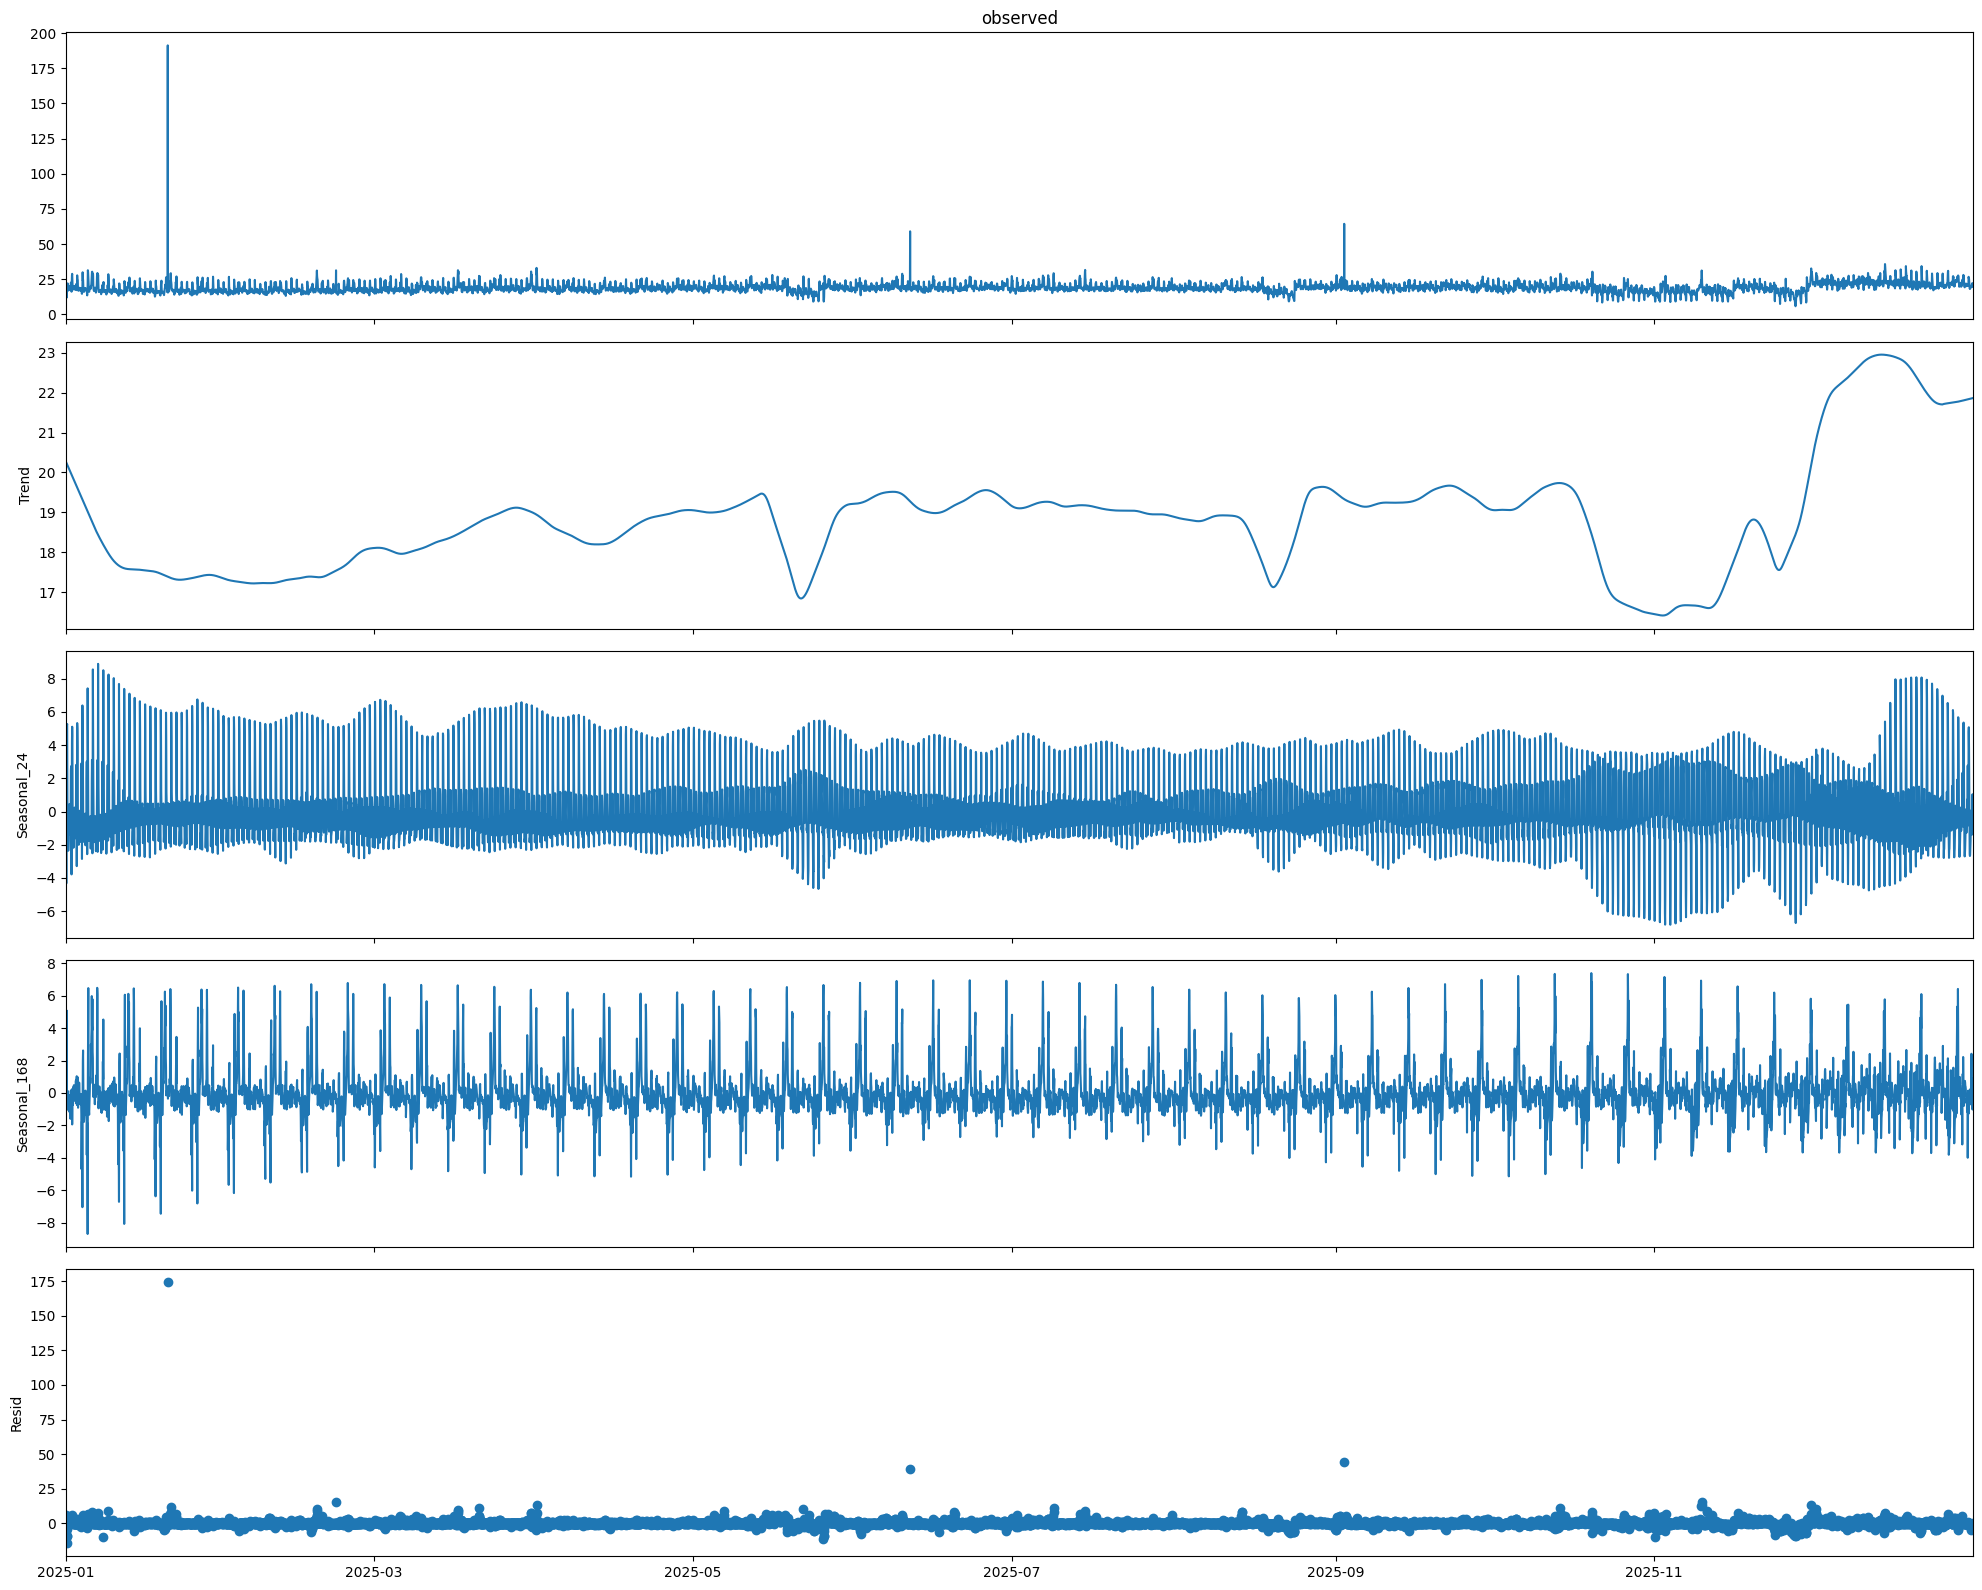

In [30]:
fig = resultado.plot()
fig.set_size_inches(20, 16)
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Sazonalidade de um dia do MSTL da Tarifa Média Horária dos Táxis Amarelos'}, xlabel='hora'>

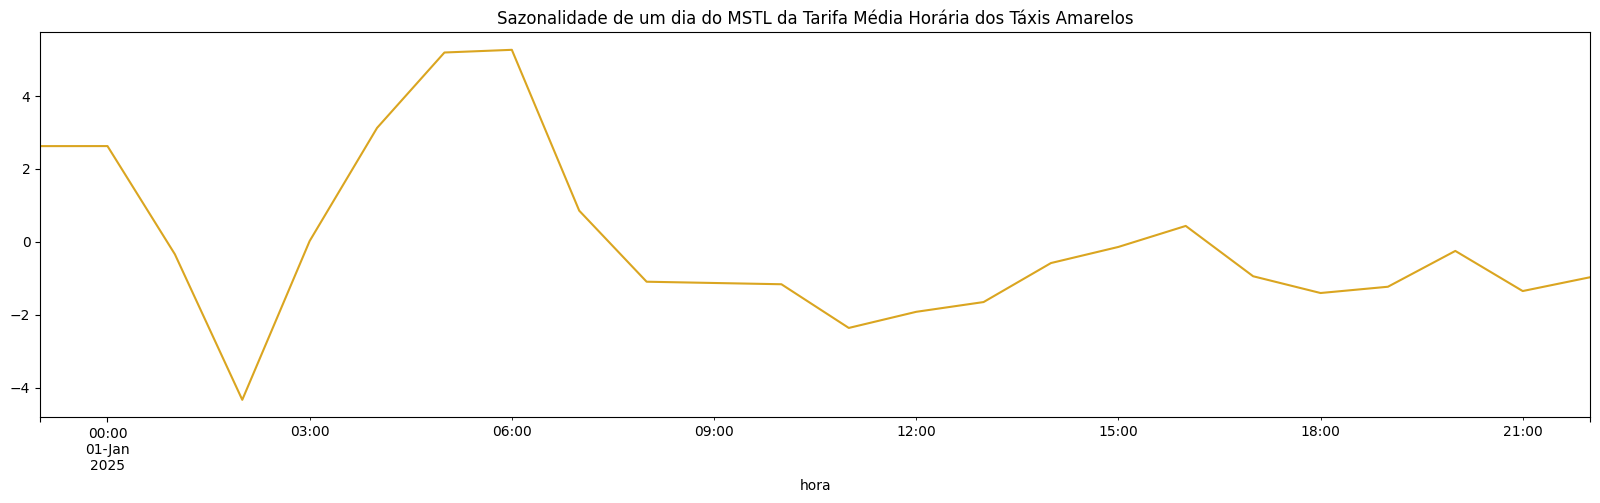

In [43]:
resultado.seasonal["seasonal_24"].iloc[:24].plot(title = 'Sazonalidade de um dia do MSTL da Tarifa Média Horária dos Táxis Amarelos', color = '#DAA520', figsize = (20, 5))

<Axes: title={'center': 'Sazonalidade de uma Semana do MSTL da Tarifa Média Horária dos Táxis Amarelos'}, xlabel='hora'>

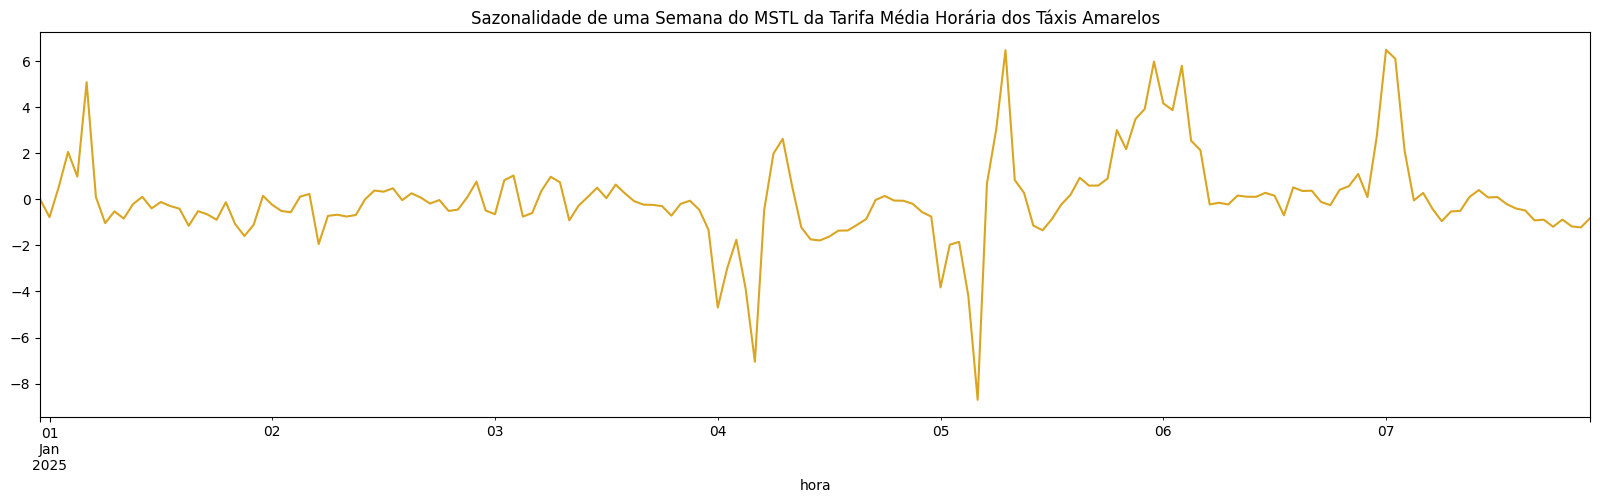

In [44]:
resultado.seasonal["seasonal_168"].iloc[:168].plot(title = 'Sazonalidade de uma Semana do MSTL da Tarifa Média Horária dos Táxis Amarelos', color = '#DAA520', figsize = (20, 5))

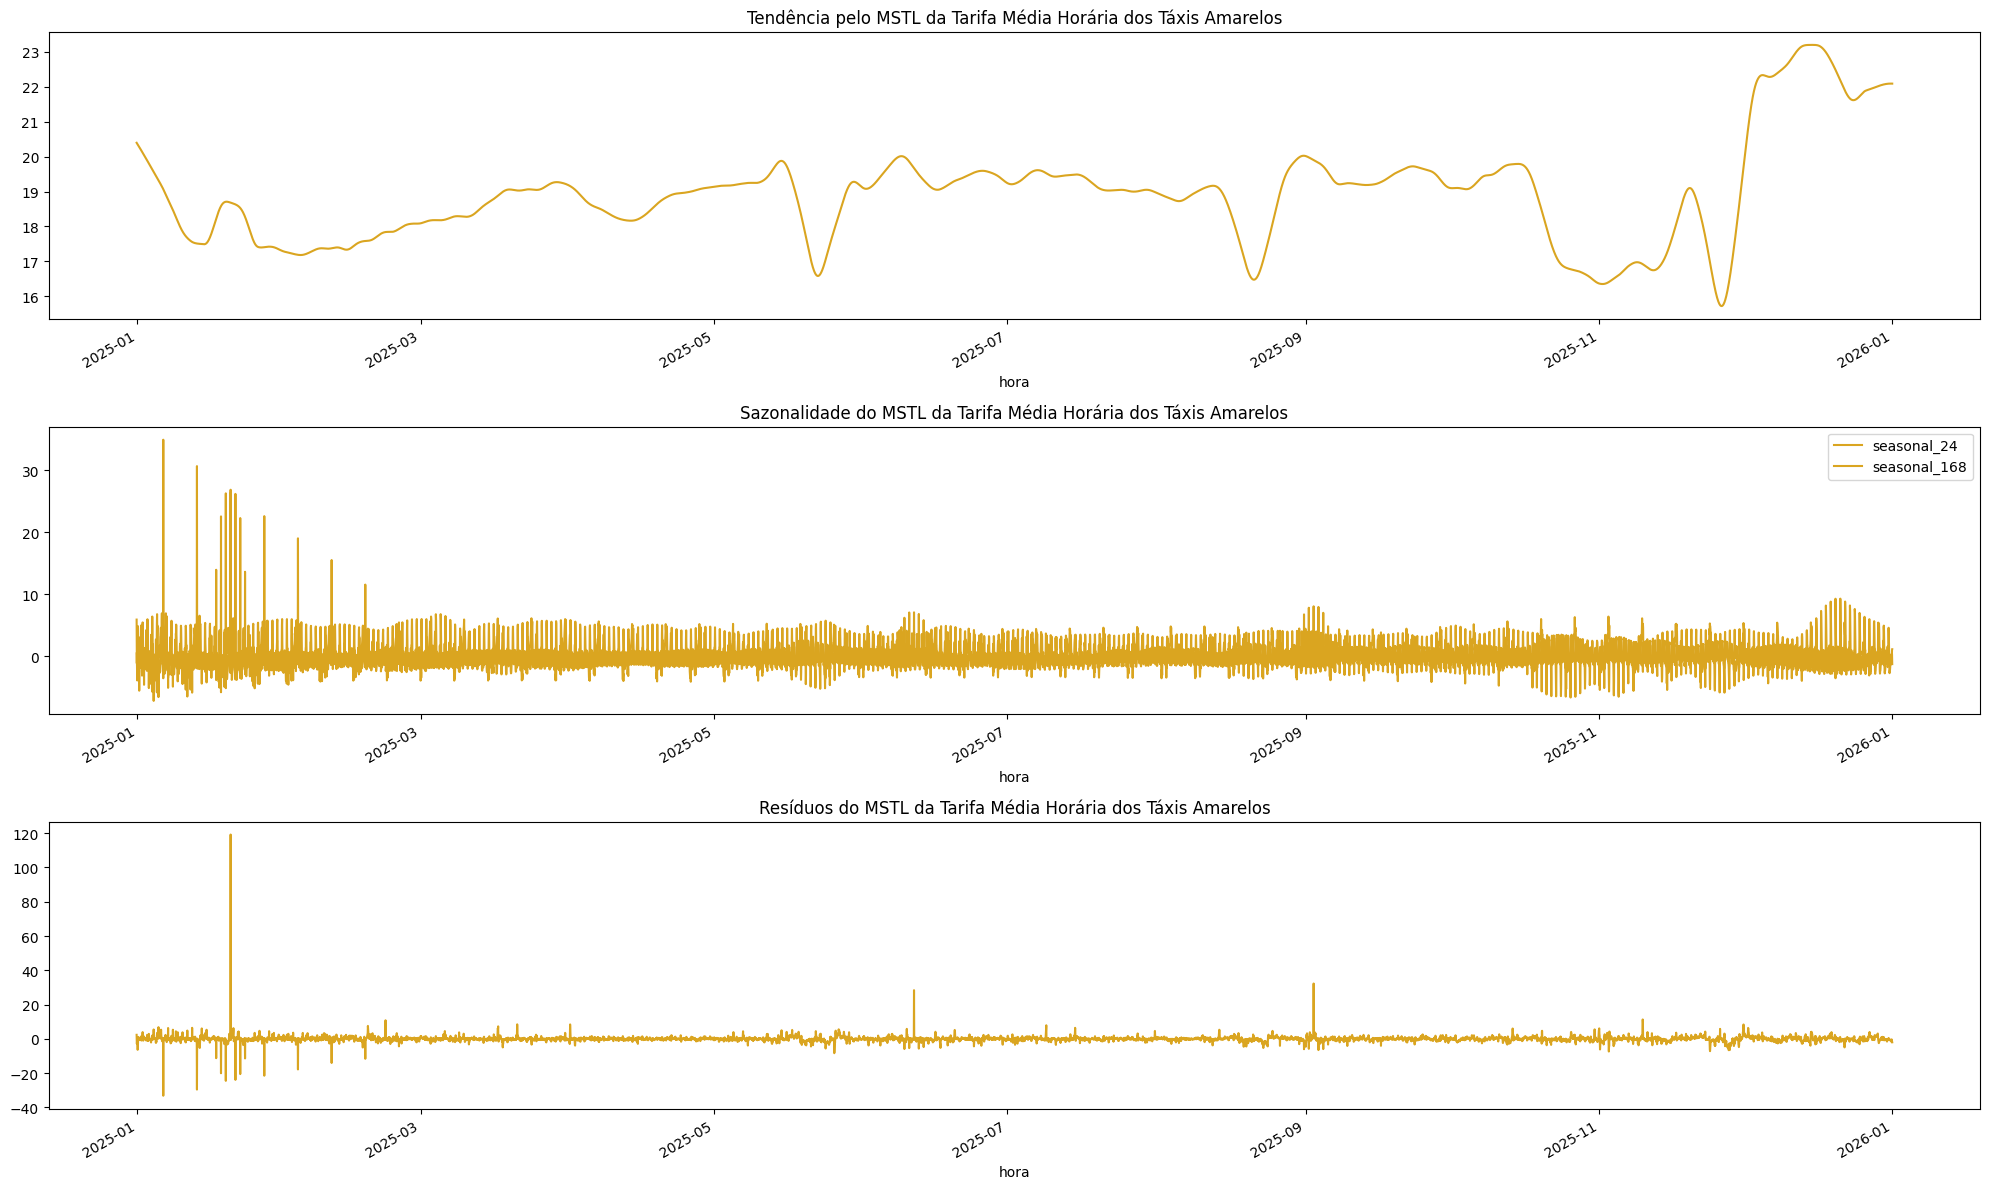

In [ ]:
resultado.seasonal["seasonal_24"].iloc[:24]

fig, axes = plt.subplots(3, 1, figsize = (20, 12))

tendencia_mstl.plot(title = 'Tendência pelo MSTL da Tarifa Média Horária dos Táxis Amarelos', color = '#DAA520', ax = axes[0])
sazonais_mstl.plot(title = 'Sazonalidade do MSTL da Tarifa Média Horária dos Táxis Amarelos', color = '#DAA520', ax = axes[1])
residuos_mstl.plot(title = 'Resíduos do MSTL da Tarifa Média Horária dos Táxis Amarelos', color = '#DAA520', ax = axes[2])

plt.tight_layout()
plt.show()

## 1. Função de Autocorrelação (ACF)

### Definição Estatística e Matemática
A Função de Autocorrelação (ACF) mede a intensidade e a direção da associação linear entre observações da mesma série temporal separadas por um intervalo de tempo $k$ (chamado de *lag* ou defasagem).

Seja $X_t$ uma série temporal fracamente estacionária com média constante $\mu = E[X_t]$ e variância constante $\sigma^2 = Var(X_t)$. A autocovariância no lag $k$, denotada por $\gamma_k$, é definida como:

$$\gamma_k = Cov(X_t, X_{t-k}) = E[(X_t - \mu)(X_{t-k} - \mu)]$$

A autocorrelação teórica no lag $k$, denotada por $\rho_k$, é a autocovariância normalizada pela variância do processo ($\gamma_0$):

$$\rho_k = \frac{\gamma_k}{\gamma_0} = \frac{E[(X_t - \mu)(X_{t-k} - \mu)]}{E[(X_t - \mu)^2]}$$

Onde $\rho_0 = 1$ e $|\rho_k| \le 1$ para todo $k$.

### Estimador Amostral (Computacional)
Dado um conjunto de dados observado com $n$ pontos de dados ($x_1, x_2, \dots, x_n$), o estimador de máxima verossimilhança da autocorrelação amostral $\hat{\rho}_k$ é calculado por:

$$\hat{\rho}_k = \frac{\hat{\gamma}_k}{\hat{\gamma}_0} = \frac{\frac{1}{n} \sum_{t=k+1}^{n} (x_t - \bar{x})(x_{t-k} - \bar{x})}{\frac{1}{n} \sum_{t=1}^{n} (x_t - \bar{x})^2}$$

Onde $\bar{x}$ é a média amostral da série inteira. Note que o denominador usa o fator de divisão $n$ (e não $n-k$) para garantir que a matriz de autocovariância resultante seja definida positiva.


### 1.2 Funcionamento Computacional Interno
Calcular as defasagens de forma sequencial utilizando loops exige uma complexidade de tempo $O(n \cdot k)$. Para conjuntos de dados massivos, isso é ineficiente. 
Internamente, bibliotecas modernas utilizam a **Transformada Rápida de Fourier (FFT)** amparada no *Teorema de Wiener-Khinchin*: 

1. A série temporal centrada na média $(x_t - \bar{x})$ é preenchida com zeros (*zero-padding*) até o comprimento de $2n$ para evitar convolução circular.
2. Calcula-se a FFT da série transformada.
3. Multiplica-se o resultado pelo seu conjugado complexo para obter o Espectro de Potência.
4. Aplica-se a Transformada Inversa de Fourier (IFFT) para retornar ao domínio do tempo, obtendo o vetor de autocovariâncias $\hat{\gamma}$.
5. Divide-se o vetor por $\hat{\gamma}_0$ para extrair os valores de $\hat{\rho}_k$.
Isso reduz a complexidade temporal para $O(n \log n)$.

### 1.3 Parâmetros na Biblioteca `statsmodels`
No Python, a função é instanciada via `statsmodels.tsa.stattools.acf`. O controle preciso de seus parâmetros garante o rigor da análise:

* **`x` (array_like):** A série temporal (unidimensional).

* **`nlags` (int, opcional):** O número de defasagens a serem calculadas. A recomendação estatística padrão é utilizar $10 \log_{10}(n)$ para evitar ruído excessivo nas caudas da amostragem.

* **`fft` (bool, padrão=False na API legada, mas recomendado True):** Define se o cálculo usará o algoritmo de Fourier. **Deve ser definido como `True`** ao lidar com os milhões de registros do TLC_NYC para evitar gargalos de processamento.

* **`alpha` (float, opcional):** Se fornecido (ex: `0.05` para 95% de confiança), a função retorna não apenas os valores da ACF, mas também os intervalos de confiança estatística baseados na aproximação de Bartlett ($\pm 1.96 / \sqrt{n}$). Útil para plotagem do 
gráfico correlograma.

* **`missing` (str, opcional):** Estratégia estatística para dados ausentes (`'none'`, `'drop'`, `'conservative'`).

* **`qstat` (bool, opcional):** Se `True`, retorna também a estatística Q de Ljung-Box para testar se um grupo de autocorrelações é significativamente diferente de zero.

### 1.4 Aplicação Prática
A ACF é primariamente utilizada para:
* Identificar a ordem $q$ de processos de **Média Móvel (MA)**: A assinatura estatística de um modelo MA($q$) é uma ACF que trunca abruptamente a zero após o lag $q$ (*cut-off*).
* Testar a estacionariedade inicial: Um decaimento extremamente lento e linear na ACF é um forte indício de que a série possui tendência e precisa ser diferenciada.

---

## 2. Função de Autocorrelação Parcial (PACF)

### Definição Estatística e Matemática
Enquanto a ACF no lag $k$ mede a correlação total entre $X_t$ e $X_{t-k}$ (incluindo os efeitos indiretos das variáveis intermediárias $X_{t-1}, X_{t-2}, \dots, X_{t-k+1}$), a PACF remove a dependência linear explicada por essas variáveis intermediárias.

Formalmente, a autocorrelação parcial no lag $k$, denotada por $\phi_{kk}$, é a correlação condicional:

$$\phi_{kk} = Corr(X_t, X_{t-k} \mid X_{t-1}, X_{t-2}, \dots, X_{t-k+1})$$

Matematicamente, ela pode ser obtida considerando a projeção linear de $X_t$ no espaço gerado por suas $k$ defasagens anteriores através de um modelo autorregressivo de ordem $k$:

$$X_t = \phi_{k1}X_{t-1} + \phi_{k2}X_{t-2} + \dots + \phi_{kk}X_{t-k} + e_t$$

Onde $\phi_{kk}$ representa o último coeficiente desse sistema.

As relações entre a ACF ($\rho$) e a PACF ($\phi$) são regidas pelas **Equações de Yule-Walker**:

$$\rho_j = \phi_{k1}\rho_{j-1} + \phi_{k2}\rho_{j-2} + \dots + \phi_{kk}\rho_{j-k}, \quad j = 1, 2, \dots, k$$

Em forma matricial para um lag $k$ genérico:

$$\begin{bmatrix} 1 & \rho_1 & \dots & \rho_{k-1} \\ \rho_1 & 1 & \dots & \rho_{k-2} \\ \vdots & \vdots & \ddots & \vdots \\ \rho_{k-1} & \rho_{k-2} & \dots & 1 \end{bmatrix} \begin{bmatrix} \phi_{k1} \\ \phi_{k2} \\ \vdots \\ \phi_{kk} \end{bmatrix} = \begin{bmatrix} \rho_1 \\ \rho_2 \\ \vdots \\ \rho_k \end{bmatrix}$$


### 2.2 Funcionamento Computacional Interno
Para obter a PACF, resolver diretamente o sistema matricial de Yule-Walker por inversão de matriz tradicional teria custo $O(k^3)$. Computacionalmente, utilizam-se duas abordagens:

1. **Algoritmo de Durbin-Levinson (Método Padrão de Amostragem):** Aproveita a estrutura simétrica de Toeplitz da matriz de autocorrelação para calcular os coeficientes de forma recursiva com custo $O(k^2)$:
   $$\phi_{kk} = \frac{\rho_k - \sum_{j=1}^{k-1} \phi_{k-1,j}\rho_{k-j}}{1 - \sum_{j=1}^{k-1} \phi_{k-1,j}\rho_j}$$
   $$\phi_{kj} = \phi_{k-1,j} - \phi_{kk}\phi_{k-1,k-j} \quad (\text{para } j = 1, \dots, k-1)$$

2. **Mínimos Quadrados Ordinários (OLS):** A PACF também pode ser calculada estimando regressões lineares consecutivas de $X_t$ contra suas defasagens via OLS para cada lag individualmente. Embora mais lento que o método recursivo, é mais robusto para séries não perfeitamente estacionárias.

### 2.3 Parâmetros na Biblioteca `statsmodels`
No Python, a função é importada via `statsmodels.tsa.stattools.pacf`. A escolha da mecânica interna é o ponto mais crítico aqui:

* **`x` (array_like):** A série temporal unidimensional.

* **`nlags` (int, opcional):** Número de defasagens. Deve ser estritamente menor que a metade do tamanho da amostra (geralmente fixado bem abaixo, como 40 ou 50 lags máximos).

* **`method` (str, padrão='ywadjusted'):** O núcleo da PACF. Define qual motor matemático será acionado:

    * `'yw'` ou `'ywadjusted'`: Utiliza as equações de Yule-Walker com ajuste para o tamanho da amostra no denominador da autocovariância. É o método padrão.

    * `'ywm'` ou `'ywmle'`: Yule-Walker sem ajuste (estimativa de máxima verossimilhança pura).

    * `'ols'`: Calcula as autocorrelações parciais rodando modelos sequenciais de Mínimos Quadrados Ordinários. **Recomendado** se o objetivo for máxima estabilidade dos coeficientes.

    * `'ldb'`: Força a utilização explícita do algoritmo de recursão de Levinson-Durbin.

* **`alpha` (float, opcional):** Fornece os intervalos de confiança estatística (ex: `0.05`). Valores da PACF fora desse intervalo indicam dependência parcial estatisticamente significativa.

### 2.4 Aplicação Prática
A PACF é primariamente utilizada para:
* Identificar a ordem $p$ de processos **Autorregressivos (AR)**: A assinatura estatística de um modelo AR($p$) é uma PACF que trunca abruptamente a zero após o lag $p$ (*cut-off*), enquanto a ACF apresenta um decaimento exponencial ou oscilatório (*tail-off*).
* Garantir a parcimônia na modelagem preditiva, fornecendo um limite claro de quantas defasagens incluir no modelo (evitando *overfitting*).

### Intervalo de Confiança Estatística
Para testar a hipótese nula de que a série é um Ruído Branco (valores independentes e identicamente distribuídos), calcula-se o intervalo de confiança padrão baseado na aproximação assintótica de Bartlett. Para um nível de significância de 5% ($\alpha = 0.05$), os limites críticos são dados por:

$$\pm \frac{1.96}{\sqrt{n}}$$

Qualquer pico de correlação que ultrapasse esses limites teóricos é considerado estatisticamente significativo, indicando memória estrutural que precisa ser modelada.

Text(0.5, 1.0, 'PACF Série temporal Média Horária de Táxi amarelo')

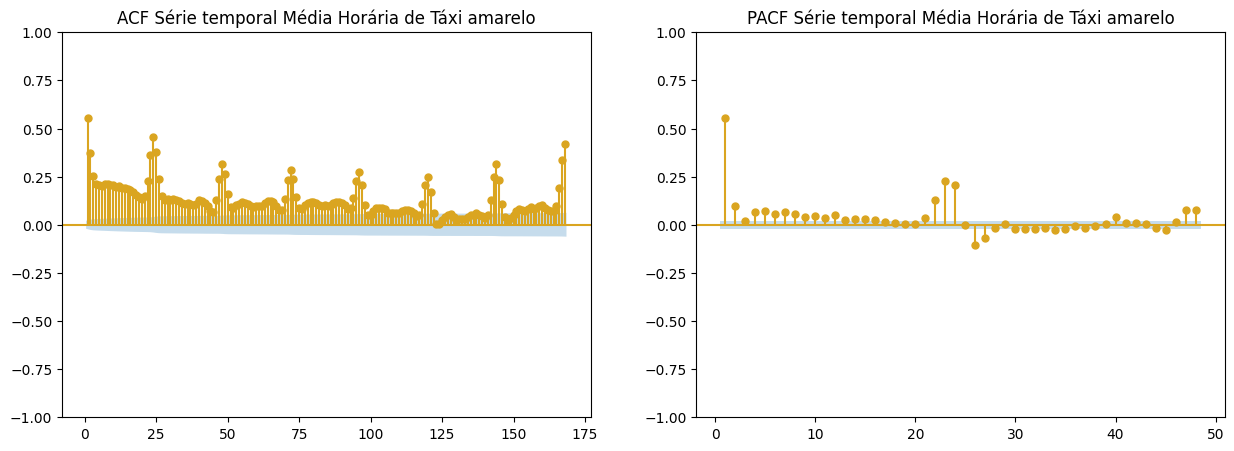

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize = (15, 5))

plot_acf(tarifa_media_horaria_yellow, lags = 168, alpha = 0.05, adjusted = False, color='#DAA520', vlines_kwargs={"colors": '#DAA520'}, zero = False, ax = axes[0])
axes[0].set_title('ACF Série temporal Média Horária de Táxi amarelo')
plot_pacf(tarifa_media_horaria_yellow, lags = 48, alpha = 0.05, method = 'ywm', color='#DAA520', vlines_kwargs={"colors": '#DAA520'}, zero = False, ax = axes[1])
axes[1].set_title('PACF Série temporal Média Horária de Táxi amarelo')

#### Conclusão ACF e PACF da Média Horária 

In [191]:
media_diaria_yellow25 = con.sql("""
SELECT DATE(tpep_pickup_datetime) AS data, 
    AVG(fare_amount) AS tarifa_media_diaria,
FROM yellow_2025 GROUP BY DATE(tpep_pickup_datetime) ORDER BY data ASC;
""").df()

media_diaria_yellow25

,data,tarifa_media_diaria
0,2024-12-31,29.137500
1,2025-01-01,17.663786
2,2025-01-02,19.096638
3,2025-01-03,18.165693
4,2025-01-04,17.616690
...,...,...
361,2025-12-27,21.730191
362,2025-12-28,22.900000
363,2025-12-29,21.634161
364,2025-12-30,21.217349


In [193]:
serie_temp_yellow = media_diaria_yellow25.copy()

serie_temp_yellow.set_index('data', inplace = True)

<Axes: title={'center': 'Série temporal dos valores médios diários de tarifa base de Taxi'}, xlabel='data'>

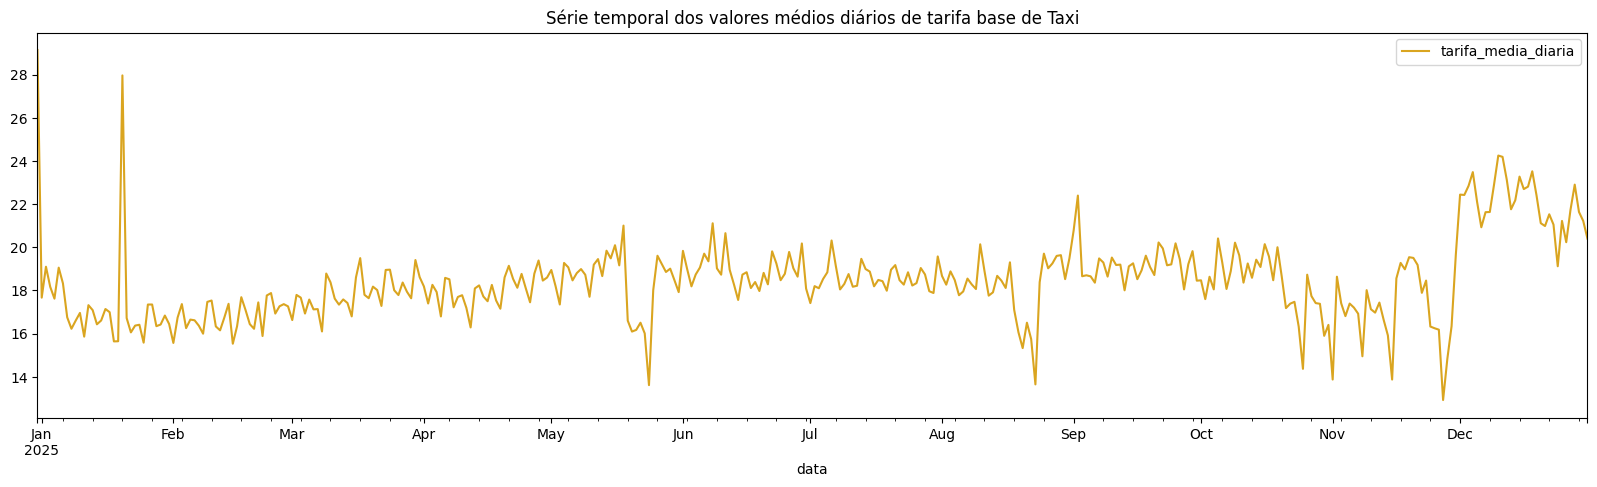

In [ ]:
serie_temp_yellow.plot(
    figsize=(20, 5), 
    color='#DAA520', 
    title='Série temporal dos valores médios diários de tarifa base de Táxi')

Text(0.5, 1.0, 'PACF Série temporal de Táxi')

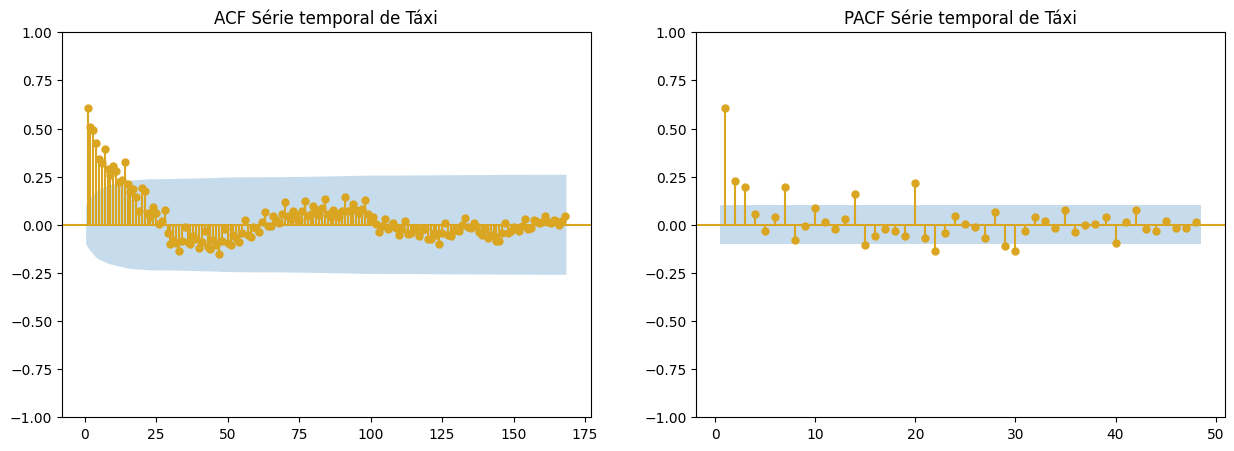

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize= (15, 5))

plot_acf(serie_temp_yellow, lags = 168, alpha = 0.05, adjusted = False, color='#DAA520', vlines_kwargs={"colors": '#DAA520'}, zero = False, ax = axes[0])
axes[0].set_title('ACF Série temporal Média Diária de Táxi amarelo')
plot_pacf(serie_temp_yellow, lags = 48, alpha = 0.05, method = 'ywm', color='#DAA520', vlines_kwargs={"colors": '#DAA520'}, zero = False, ax = axes[1])
axes[1].set_title('PACF Série temporal Média Diária de Táxi amarelo')

In [216]:
inicio_yellow2025 = con.sql("""
SELECT PULocationID, COUNT(PULocationID) AS taxis_amarelos_tomados FROM yellow_2025
GROUP BY PULocationID ORDER BY taxis_amarelos_tomados DESC;
""").df()

inicio_yellow2025

,PULocationID,taxis_amarelos_tomados
0,237,2125551
1,161,2089733
2,132,2062336
3,236,1874796
4,186,1543149
...,...,...
257,204,29
258,5,20
259,199,18
260,99,7


In [217]:
dicio_chegada

,PULocationID,Borough,Zone
0,1,EWR,Newark Airport
1,2,Queens,Jamaica Bay
2,3,Bronx,Allerton/Pelham Gardens
3,4,Manhattan,Alphabet City
4,5,Staten Island,Arden Heights
...,...,...,...
260,261,Manhattan,World Trade Center
261,262,Manhattan,Yorkville East
262,263,Manhattan,Yorkville West
263,264,Unknown,N/A


In [ ]:
teste = inicio_yellow2025.copy()

teste = teste.merge(dicio_chegada, on='PULocationID', how='left')

# Agora o rename vai funcionar perfeitamente
teste.rename(columns={'Borough': 'bairro_partida', 'Zone': 'Zona_partida'}, inplace=True)

# Reordenação das colunas
colunas_sem_partida = [col for col in teste.columns if col not in ['bairro_partida', 'Zona_partida']]
nova_ordem_partida = ['bairro_partida', 'Zona_partida'] + colunas_sem_partida
teste = teste[nova_ordem_partida]

teste.drop(columns = 'PULocationID')

,bairro_partida,Zona_partida,taxis_amarelos_tomados
0,Manhattan,Upper East Side South,2125551
1,Manhattan,Midtown Center,2089733
2,Queens,JFK Airport,2062336
3,Manhattan,Upper East Side North,1874796
4,Manhattan,Penn Station/Madison Sq West,1543149
...,...,...,...
257,Staten Island,Rossville/Woodrow,29
258,Staten Island,Arden Heights,20
259,Bronx,Rikers Island,18
260,Staten Island,Freshkills Park,7


In [158]:
destino_yellow2025 = con.sql("""
SELECT DOLocationID, COUNT(DOLocationID) AS destino_taxis_amarelos FROM yellow_2025
GROUP BY DOLocationID ORDER BY destino_taxis_amarelos DESC;
""").df()

destino_yellow2025

,DOLocationID,destino_taxis_amarelos
0,236,1939209
1,237,1927506
2,161,1726985
3,230,1451507
4,170,1347336
...,...,...
258,2,125
259,99,18
260,105,8
261,199,3


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

caminho_shapefile = "C:/Users/mayma/Documents/Projetos/NYC_TLC_Database/taxi_zones/taxi_zones.shp"
mapa_zonas = gpd.read_file(caminho_shapefile)

mapa_zonas

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."
...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ..."
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ..."
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19..."
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824...."


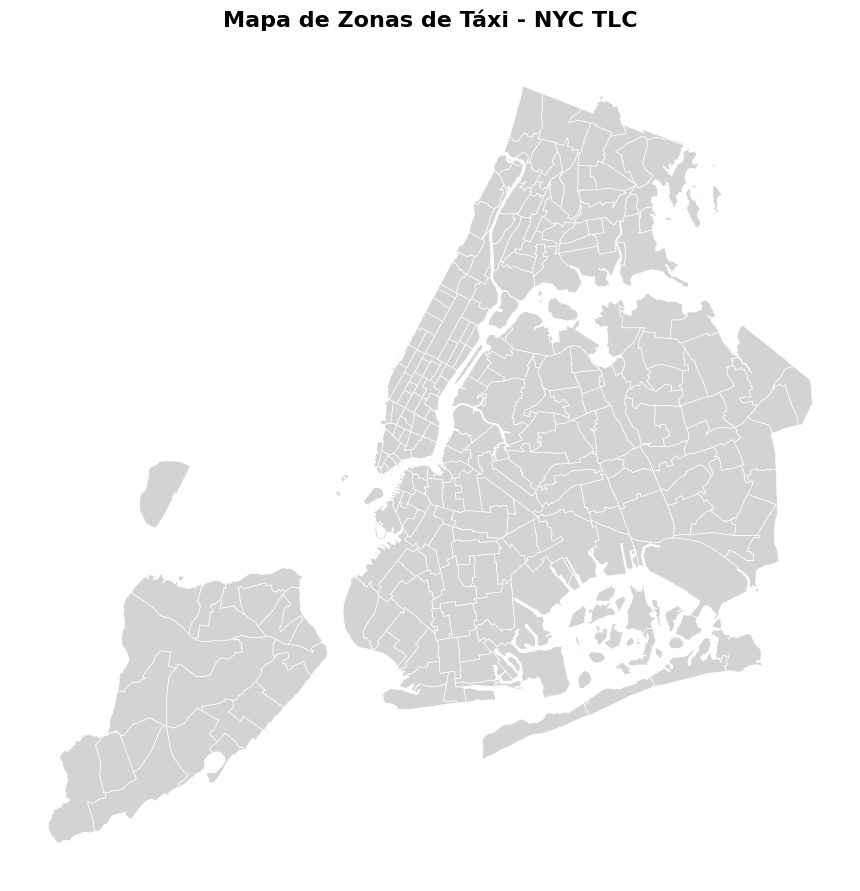

In [5]:
fig, ax = plt.subplots(figsize=(9, 9))

# 3. Plotar o mapa básico das zonas de táxi
mapa_zonas.plot(
    ax=ax, 
    color='lightgrey',      # Cor de fundo dos bairros
    edgecolor='white',      # Cor das linhas divisórias
    linewidth=0.5           # Espessura das linhas
)

# 4. Ajustes estéticos profissionais
ax.set_title("Mapa de Zonas de Táxi - NYC TLC", fontsize=16, fontweight='bold', pad=15)
ax.axis('off')  # Remove as coordenadas de latitude/longitude para limpar o visual

# 5. Exibir o mapa na tela
plt.tight_layout()
plt.show()

In [160]:
inicio_yellow2025 = inicio_yellow2025.rename(columns = {'PULocationID': 'LocationID'}) 
destino_yellow2025 = destino_yellow2025.rename(columns = {'DOLocationID': 'LocationID'})

mapa_origens = mapa_zonas.merge(inicio_yellow2025, on='LocationID', how='left')
mapa_destinos = mapa_zonas.merge(destino_yellow2025, on='LocationID', how='left')

mapa_origens

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,taxis_amarelos_tomados
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",6056.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",69.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",4651.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",157793.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",20.0
...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",7761.0
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",36260.0
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",252043.0
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",641070.0


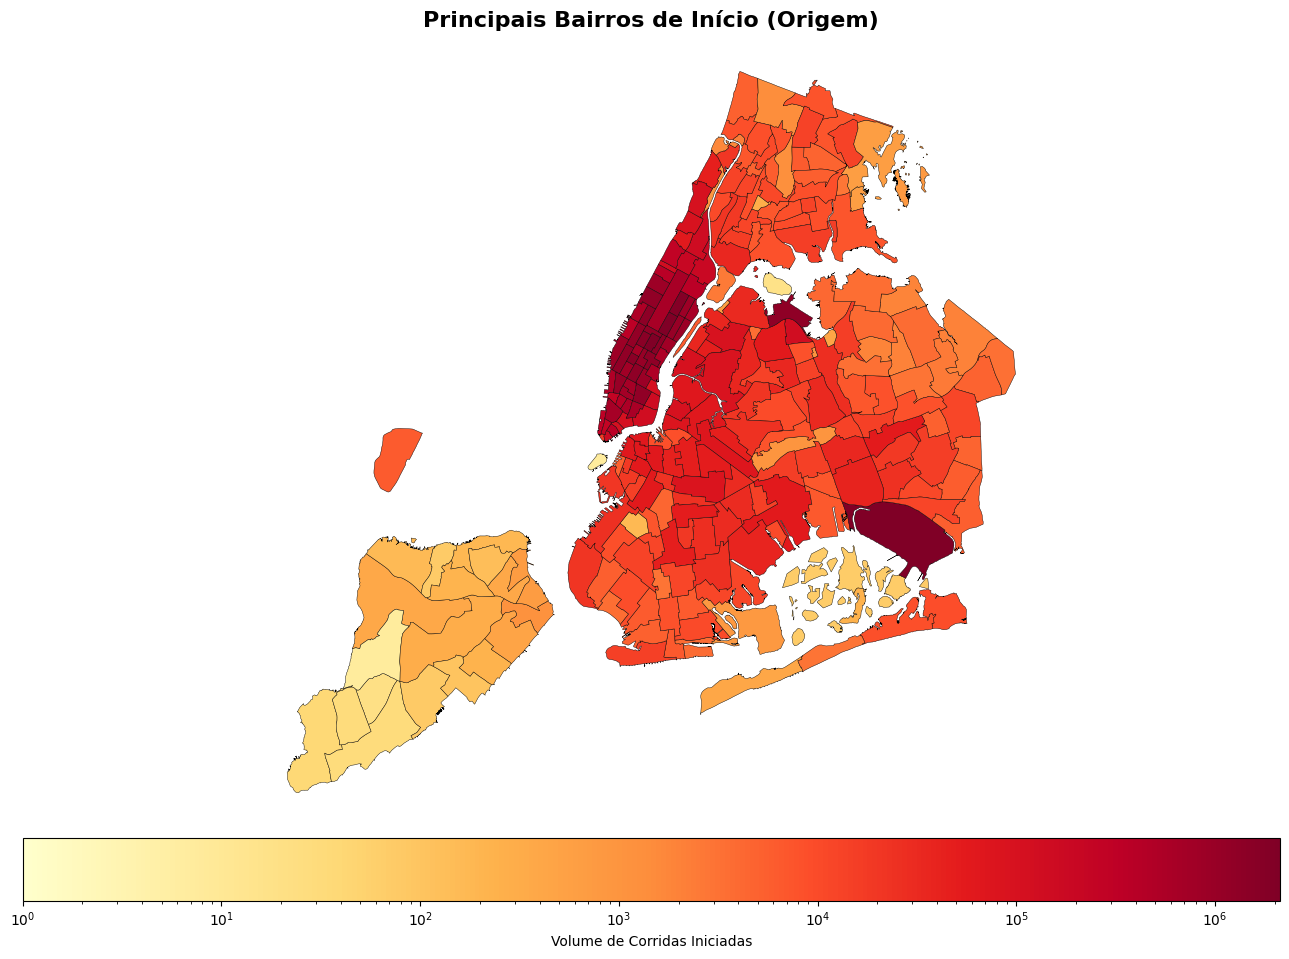

In [229]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(figsize=(13, 10))

mapa_origens.plot(
    column='taxis_amarelos_tomados', 
    cmap='YlOrRd',          
    linewidth=0.3, 
    ax=axes, 
    edgecolor='black', 
    legend=True,
    norm=LogNorm(vmin=1, vmax=mapa_origens['taxis_amarelos_tomados'].max()),
    legend_kwds={'label': "Volume de Corridas Iniciadas", 'orientation': "horizontal", 'pad': 0.01}
)
axes.set_title("Principais Bairros de Início (Origem)", fontsize=16, fontweight='bold')
axes.axis('off')

plt.tight_layout()
plt.show()

---

# Dados Green Taxi Trip Records 

In [109]:
con.sql("""
SELECT * FROM green_2025 LIMIT 10;
""")

┌──────────┬──────────────────────┬───────────────────────┬────────────────────┬────────────┬──────────────┬──────────────┬─────────────────┬───────────────┬─────────────┬────────┬─────────┬────────────┬──────────────┬───────────┬───────────────────────┬──────────────┬──────────────┬───────────┬──────────────────────┬────────────────────┐
│ VendorID │ lpep_pickup_datetime │ lpep_dropoff_datetime │ store_and_fwd_flag │ RatecodeID │ PULocationID │ DOLocationID │ passenger_count │ trip_distance │ fare_amount │ extra  │ mta_tax │ tip_amount │ tolls_amount │ ehail_fee │ improvement_surcharge │ total_amount │ payment_type │ trip_type │ congestion_surcharge │ cbd_congestion_fee │
│  int32   │      timestamp       │       timestamp       │      varchar       │   int64    │    int32     │    int32     │      int64      │    double     │   double    │ double │ double  │   double   │    double    │  double   │        double         │    double    │    int64     │   int64   │        double        

In [22]:
con.sql("""
DESCRIBE SELECT * FROM green_2025;
""")

┌───────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name      │ column_type │  null   │   key   │ default │  extra  │
│        varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ VendorID              │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ lpep_pickup_datetime  │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ lpep_dropoff_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ store_and_fwd_flag    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ RatecodeID            │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ PULocationID          │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ DOLocationID          │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ passenger_count       │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ trip_distance         │ DOUBLE      │ 

In [40]:
Media_tarifa = con.sql("""
SELECT
    AVG(fare_amount) AS tarifa_media
FROM green_2025;
""").df()

Media_tarifa

,tarifa_media
0,18.088083


In [171]:
con.sql("""
SELECT COUNT(*) AS linhas_green25 FROM green_2025;
""")

┌────────────────┐
│ linhas_green25 │
│     int64      │
├────────────────┤
│         591348 │
└────────────────┘

In [36]:
prejuizo = con.sql("""
SELECT SUM(total_amount) AS Viagens_comprometidas FROM green_2025 WHERE total_amount < 0;
""").df()

prejuizo

,Viagens_comprometidas
0,-25146.18


In [102]:
receita_green = con.sql("""
SELECT SUM(total_amount) AS Receita_liquida_green2025 FROM green_2025;
""").df()

receita_green

,Receita_liquida_green2025
0,14905966.99


In [42]:
df_pagamentos = con.sql("""
SELECT 
    CASE 
        WHEN payment_type = 0 THEN 'Flex Fare'
        WHEN payment_type = 1 THEN 'Credit Card'
        WHEN payment_type = 2 THEN 'Cash'
        WHEN payment_type = 3 THEN 'No Charge'
        WHEN payment_type = 4 THEN 'Dispute'
        WHEN payment_type = 5 THEN 'Unknown'
        WHEN payment_type = 6 THEN 'Voided'
        ELSE 'Other'
    END AS tipo_pagamento,
    COUNT(*) AS contagem
FROM green_2025
GROUP BY payment_type
ORDER BY contagem DESC;
""").df()

df_pagamentos

,tipo_pagamento,contagem
0,Credit Card,406599
1,Cash,129818
2,Other,49880
3,No Charge,3784
4,Dispute,1244
5,Unknown,23


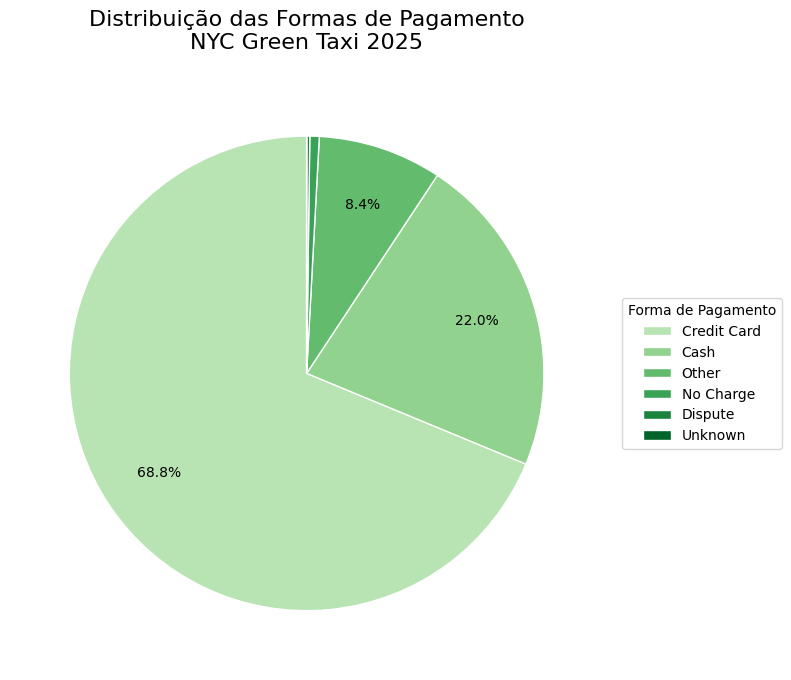

In [43]:
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(df_pagamentos)))

fig, ax = plt.subplots(figsize=(8, 8))

def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

wedges, texts, autotexts = ax.pie(
    df_pagamentos["contagem"],
    autopct=autopct_format,
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

ax.legend(
    wedges,
    df_pagamentos["tipo_pagamento"],
    title="Forma de Pagamento",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

ax.set_title(
    "Distribuição das Formas de Pagamento\nNYC Green Taxi 2025",
    fontsize=16,
    pad=20
)

plt.tight_layout()
plt.show()

In [230]:
rotas_green_2025 = con.sql("""
SELECT PULocationID, DOLocationID, COUNT(*) AS taxis_verdes_tomados, 
       AVG(fare_amount) AS tarifa_media, AVG(trip_distance) AS distancia_media FROM green_2025
GROUP BY PULocationID, DOLocationID ORDER BY taxis_verdes_tomados DESC LIMIT 15;
""").df()

rotas_green_2025

,PULocationID,DOLocationID,taxis_verdes_tomados,tarifa_media,distancia_media
0,74,75,23607,11.175362,1.447131
1,74,236,16355,14.203971,4.993850
2,75,74,14886,8.987160,1.277971
3,74,166,10015,13.316627,1.769864
4,74,263,8520,14.166825,2.224708
5,95,95,8344,10.241239,5.224493
6,74,238,8288,17.770210,2.765703
7,74,41,8077,9.439146,2.462605
8,75,236,6927,8.691140,0.982193
9,74,74,6792,8.711689,0.802133


In [231]:
rotas_green_2025 = rotas_green_2025.merge(dicio_chegada, on='PULocationID', how='left')

rotas_green_2025.rename(columns={'Borough': 'bairro_partida', 'Zone': 'Zona_partida'}, inplace=True)

colunas_sem_partida = [col for col in rotas_green_2025.columns if col not in ['bairro_partida', 'Zona_partida']]
nova_ordem_partida = ['bairro_partida', 'Zona_partida'] + colunas_sem_partida
rotas_green_2025 = rotas_green_2025[nova_ordem_partida]

rotas_green_2025 = rotas_green_2025.merge(dicio_destino, on='DOLocationID', how='left')

rotas_green_2025.rename(columns={'Borough': 'bairro_destino', 'Zone': 'Zona_destino'}, inplace=True)

colunas_restantes = [col for col in rotas_green_2025.columns if col not in ['bairro_partida', 'Zona_partida', 'bairro_destino', 'Zona_destino']]
nova_ordem_final = ['bairro_partida', 'Zona_partida', 'bairro_destino', 'Zona_destino'] + colunas_restantes
rotas_green_2025 = rotas_green_2025[nova_ordem_final]

rotas_green_2025.drop(columns = ['PULocationID', 'DOLocationID'])

,bairro_partida,Zona_partida,bairro_destino,Zona_destino,taxis_verdes_tomados,tarifa_media,distancia_media
0,Manhattan,East Harlem North,Manhattan,East Harlem South,23607,11.175362,1.447131
1,Manhattan,East Harlem North,Manhattan,Upper East Side North,16355,14.203971,4.993850
2,Manhattan,East Harlem South,Manhattan,East Harlem North,14886,8.987160,1.277971
3,Manhattan,East Harlem North,Manhattan,Morningside Heights,10015,13.316627,1.769864
4,Manhattan,East Harlem North,Manhattan,Yorkville West,8520,14.166825,2.224708
5,Queens,Forest Hills,Queens,Forest Hills,8344,10.241239,5.224493
6,Manhattan,East Harlem North,Manhattan,Upper West Side North,8288,17.770210,2.765703
7,Manhattan,East Harlem North,Manhattan,Central Harlem,8077,9.439146,2.462605
8,Manhattan,East Harlem South,Manhattan,Upper East Side North,6927,8.691140,0.982193
9,Manhattan,East Harlem North,Manhattan,East Harlem North,6792,8.711689,0.802133


In [118]:
media_horaria_green2025 = con.sql("""
SELECT DATE_TRUNC('hour', lpep_pickup_datetime) AS data_horas, 
    AVG(fare_amount) AS tarifa_media_horaria,
FROM green_2025 GROUP BY DATE_TRUNC('hour', lpep_pickup_datetime) ORDER BY data_horas ASC;
""").df()

media_horaria_green2025

,data_horas,tarifa_media_horaria
0,2025-01-01 00:00:00,21.882836
1,2025-01-01 01:00:00,24.354815
2,2025-01-01 02:00:00,23.929130
3,2025-01-01 03:00:00,22.434500
4,2025-01-01 04:00:00,23.316970
...,...,...
8749,2025-12-31 19:00:00,15.694235
8750,2025-12-31 20:00:00,16.059494
8751,2025-12-31 21:00:00,19.107949
8752,2025-12-31 22:00:00,21.809123


In [ ]:
serie_tem_green = media_horaria_green2025.copy()

serie_tem_green.set_index('data_horas', inplace = True)

<Axes: title={'center': 'Série temporal dos valores médios horários de tarifa base de Táxi Verde'}, xlabel='data_horas'>

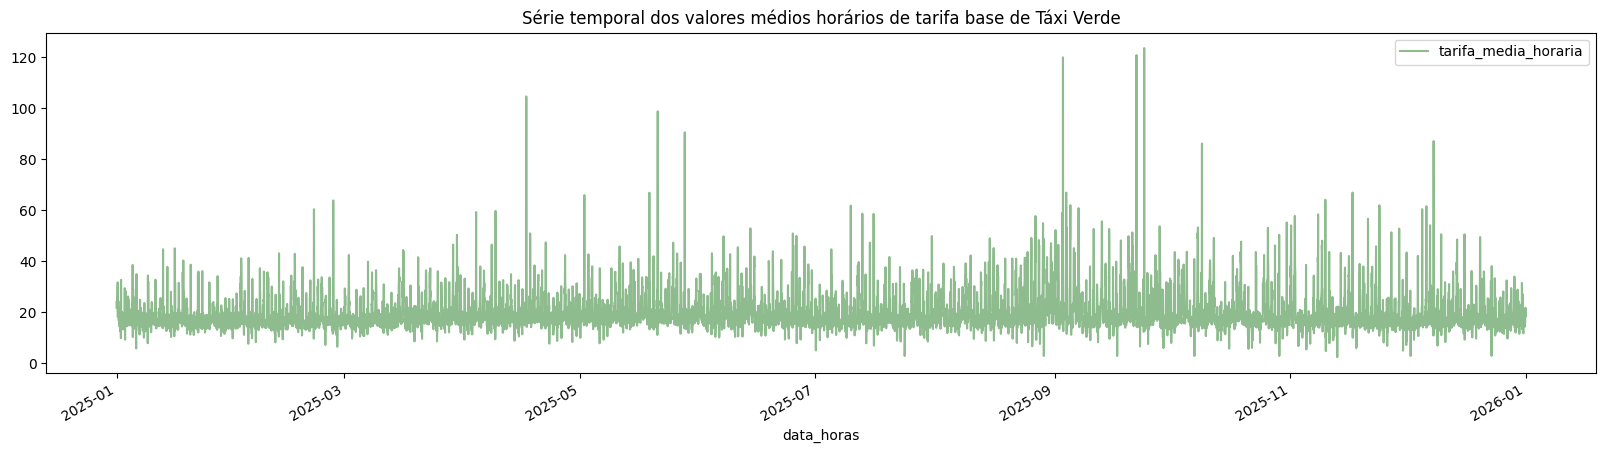

In [234]:
serie_tem_green.plot(
    figsize=(20, 5), 
    color='darkseagreen', 
    title='Série temporal dos valores médios horários de tarifa base de Táxi Verde')

In [ ]:
media_diaria_green2025 = con.sql("""
SELECT DATE(lpep_pickup_datetime) AS data, 
    AVG(fare_amount) AS tarifa_media_diaria,
FROM green_2025 GROUP BY DATE(lpep_pickup_datetime) ORDER BY data ASC;
""").df()

media_diaria_green2025

,data,tarifa_media_horaria
0,2025-01-01,19.376014
1,2025-01-02,16.925185
2,2025-01-03,17.841187
3,2025-01-04,17.299952
4,2025-01-05,17.759442
...,...,...
360,2025-12-27,17.397429
361,2025-12-28,17.888623
362,2025-12-29,17.271378
363,2025-12-30,16.753705


In [120]:
serie_diaria_green = media_diaria_green2025.copy()

serie_diaria_green.set_index('data', inplace = True)

<Axes: title={'center': 'Série temporal dos valores médios diários de tarifa base de Táxi Verde'}, xlabel='data'>

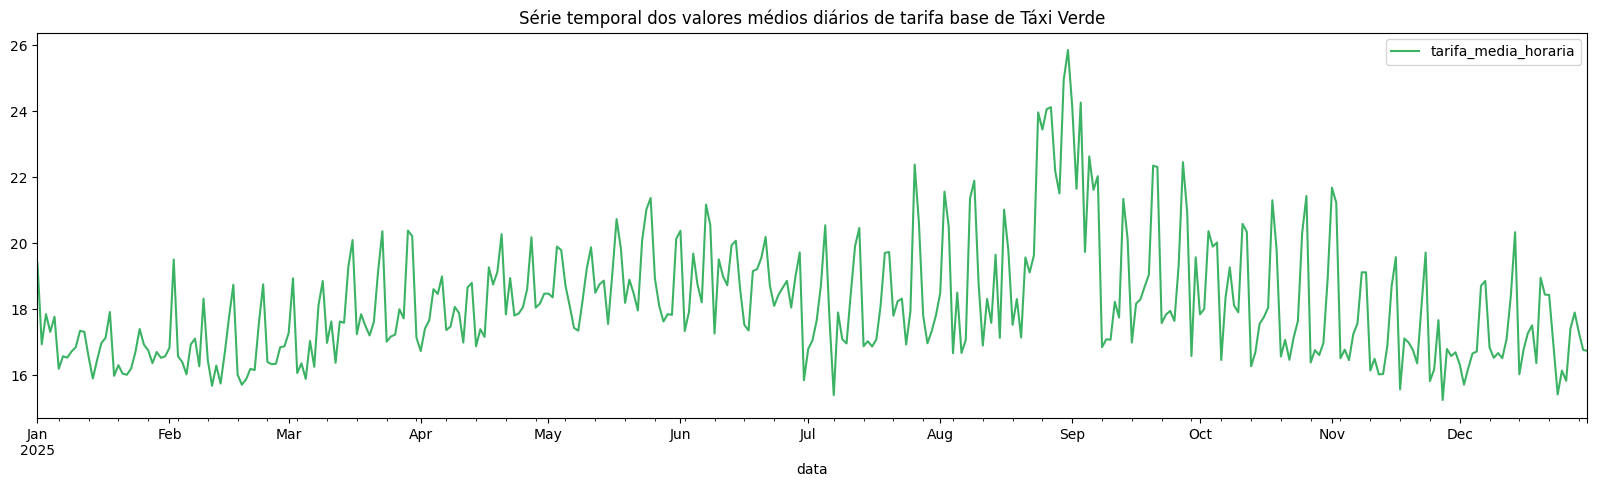

In [235]:
serie_diaria_green.plot(
    figsize=(20, 5), 
    color="#3CB364", 
    title='Série temporal dos valores médios diários de tarifa base de Táxi Verde')

---

# Dados High Volume FHV Trip Records 


In [172]:
con.sql("""
SELECT COUNT(*) AS linhas_fhvhv25 FROM fhvhv_2025
""")

┌────────────────┐
│ linhas_fhvhv25 │
│     int64      │
├────────────────┤
│      243589684 │
└────────────────┘

In [48]:
receita = con.sql("""
SELECT AVG(base_passenger_fare) AS linhas_fhvhv25 FROM fhvhv_2025;
""").df()

receita

,linhas_fhvhv25
0,26.947717


In [6]:
info_fhvhv2025 = con.sql("""SUMMARIZE fhvhv_2025""").df()

info_fhvhv2025

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,hvfhs_license_num,VARCHAR,HV0003,HV0005,1,None,None,None,None,None,243589684,0.00
1,dispatching_base_num,VARCHAR,B03404,B03406,2,None,None,None,None,None,243589684,0.00
2,originating_base_num,VARCHAR,B00887,B03406,7,None,None,None,None,None,243589684,27.66
3,request_datetime,TIMESTAMP,2024-12-31 22:31:09,2026-01-01 00:25:53,26450892,2025-07-03 15:11:47.199182,None,2025-04-02 09:12:11.017104,2025-07-02 21:05:01.016337,2025-10-06 04:39:51.973072,243589684,0.00
4,on_scene_datetime,TIMESTAMP,2024-12-31 23:25:35,2025-12-31 23:59:58,26450892,2025-07-10 16:09:19.720408,None,2025-04-14 08:23:56.969738,2025-07-10 18:17:00.015733,2025-10-09 23:47:38.639003,243589684,4.46
5,pickup_datetime,TIMESTAMP,2025-01-01 00:00:00,2025-12-31 23:59:59,26450892,2025-07-03 15:16:27.974839,None,2025-04-02 09:44:28.433955,2025-07-02 13:57:57.790107,2025-10-05 14:55:28.92894,243589684,0.00
6,dropoff_datetime,TIMESTAMP,2025-01-01 00:01:48,2026-01-01 03:07:41,25577413,2025-07-03 15:36:20.413151,None,2025-04-01 23:03:52.69202,2025-07-02 11:32:14.674768,2025-10-06 02:03:20.488124,243589684,0.00
7,PULocationID,INTEGER,1,265,298,138.27084576783636,74.84433331409758,75,139,208,243589684,0.00
8,DOLocationID,INTEGER,1,265,298,142.19760995707847,78.11934785275236,75,141,217,243589684,0.00
9,trip_miles,DOUBLE,0.0,5380.78,103659,5.032854566945969,5.901956332273887,1.536215404160129,2.9887070631768857,6.316490762116893,243589684,0.00


In [7]:
con.sql("""SELECT * FROM fhvhv_2025 LIMIT 10""")

┌───────────────────┬──────────────────────┬──────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬──────────────┬──────────────┬────────────┬───────────┬─────────────────────┬────────┬────────┬───────────┬──────────────────────┬─────────────┬────────┬────────────┬─────────────────────┬───────────────────┬────────────────────┬──────────────────┬────────────────┬────────────────────┐
│ hvfhs_license_num │ dispatching_base_num │ originating_base_num │  request_datetime   │  on_scene_datetime  │   pickup_datetime   │  dropoff_datetime   │ PULocationID │ DOLocationID │ trip_miles │ trip_time │ base_passenger_fare │ tolls  │  bcf   │ sales_tax │ congestion_surcharge │ airport_fee │  tips  │ driver_pay │ shared_request_flag │ shared_match_flag │ access_a_ride_flag │ wav_request_flag │ wav_match_flag │ cbd_congestion_fee │
│      varchar      │       varchar        │       varchar        │      timestamp      │      timestamp      │     

In [103]:
receita_liquida_fhvhv = con.sql("""
SELECT 
    SUM(CASE WHEN hvfhs_license_num = 'HV0003' THEN driver_pay ELSE 0 END) AS Total_Uber,
    SUM(CASE WHEN hvfhs_license_num = 'HV0005' THEN driver_pay ELSE 0 END) AS Total_Lyft,
FROM fhvhv_2025;
""").df()

receita_liquida_fhvhv

,Total_Uber,Total_Lyft
0,3.721442e+09,1.348581e+09


In [237]:
rotas_fhvhv2025 = con.sql("""
SELECT PULocationID, DOLocationID, COUNT(*) AS corridas_tomadas, 
       AVG(base_passenger_fare) AS tarifa_media, AVG(trip_miles) AS distancia_media FROM fhvhv_2025
GROUP BY PULocationID, DOLocationID ORDER BY corridas_tomadas DESC LIMIT 15;
""").df()

rotas_fhvhv2025

,PULocationID,DOLocationID,corridas_tomadas,tarifa_media,distancia_media
0,76,76,849410,10.382879,1.406512
1,132,265,820778,115.452161,30.668878
2,138,265,672794,110.304535,27.007611
3,39,39,528035,9.778913,1.230413
4,26,26,478514,10.971716,1.096638
5,61,61,395580,10.866853,1.210822
6,14,14,367067,9.615880,1.131456
7,95,95,338336,10.091650,1.151540
8,129,129,334001,10.002425,1.128294
9,7,7,331265,9.312975,0.986042


In [238]:
rotas_fhvhv2025 = rotas_fhvhv2025.merge(dicio_chegada, on='PULocationID', how='left')

rotas_fhvhv2025.rename(columns={'Borough': 'bairro_partida', 'Zone': 'Zona_partida'}, inplace=True)

colunas_sem_partida = [col for col in rotas_fhvhv2025.columns if col not in ['bairro_partida', 'Zona_partida']]
nova_ordem_partida = ['bairro_partida', 'Zona_partida'] + colunas_sem_partida
rotas_fhvhv2025 = rotas_fhvhv2025[nova_ordem_partida]

rotas_fhvhv2025 = rotas_fhvhv2025.merge(dicio_destino, on='DOLocationID', how='left')

rotas_fhvhv2025.rename(columns={'Borough': 'bairro_destino', 'Zone': 'Zona_destino'}, inplace=True)

colunas_restantes = [col for col in rotas_fhvhv2025.columns if col not in ['bairro_partida', 'Zona_partida', 'bairro_destino', 'Zona_destino']]
nova_ordem_final = ['bairro_partida', 'Zona_partida', 'bairro_destino', 'Zona_destino'] + colunas_restantes
rotas_fhvhv2025 = rotas_fhvhv2025[nova_ordem_final]

rotas_fhvhv2025.drop(columns = ['PULocationID', 'DOLocationID'])

,bairro_partida,Zona_partida,bairro_destino,Zona_destino,corridas_tomadas,tarifa_media,distancia_media
0,Brooklyn,East New York,Brooklyn,East New York,849410,10.382879,1.406512
1,Queens,JFK Airport,N/A,Outside of NYC,820778,115.452161,30.668878
2,Queens,LaGuardia Airport,N/A,Outside of NYC,672794,110.304535,27.007611
3,Brooklyn,Canarsie,Brooklyn,Canarsie,528035,9.778913,1.230413
4,Brooklyn,Borough Park,Brooklyn,Borough Park,478514,10.971716,1.096638
5,Brooklyn,Crown Heights North,Brooklyn,Crown Heights North,395580,10.866853,1.210822
6,Brooklyn,Bay Ridge,Brooklyn,Bay Ridge,367067,9.615880,1.131456
7,Queens,Forest Hills,Queens,Forest Hills,338336,10.091650,1.151540
8,Queens,Jackson Heights,Queens,Jackson Heights,334001,10.002425,1.128294
9,Queens,Astoria,Queens,Astoria,331265,9.312975,0.986042


In [236]:
media_mes = con.sql("""
SELECT MONTH(pickup_datetime) AS Meses, 
    SUM(CASE WHEN hvfhs_license_num = 'HV0003' THEN driver_pay ELSE 0 END) AS Total_Uber,
    SUM(CASE WHEN hvfhs_license_num = 'HV0005' THEN driver_pay ELSE 0 END) AS Total_Lyft,
FROM fhvhv_2025 GROUP BY MONTH(pickup_datetime) ORDER BY Meses ASC;
""").df()

media_mes

,Meses,Total_Uber,Total_Lyft
0,1,2.908052e+08,8.977982e+07
1,2,2.796975e+08,9.015201e+07
2,3,3.004452e+08,1.180325e+08
3,4,2.932282e+08,1.080395e+08
4,5,3.318617e+08,1.257918e+08
5,6,3.160678e+08,1.138174e+08
6,7,2.988722e+08,1.085476e+08
7,8,2.866610e+08,1.143769e+08
8,9,3.154855e+08,1.128009e+08
9,10,3.384605e+08,1.222551e+08


In [ ]:
media_mes = con.sql("""
SELECT MONTH(pickup_datetime) AS Meses, 
    AVG(driver_pay) FILTER (WHERE hvfhs_license_num = 'HV0003') AS media_mes_Uber,
    AVG(driver_pay) FILTER (WHERE hvfhs_license_num = 'HV0005') AS media_mes_Lyft,
FROM fhvhv_2025 GROUP BY MONTH(pickup_datetime) ORDER BY Meses ASC;
""").df()

media_mes

,Meses,media_mes_Uber,media_mes_Lyft
0,1,18.936998,17.780961
1,2,19.397007,18.324182
2,3,20.653157,19.705926
3,4,20.419052,20.031570
4,5,22.066932,20.784053
5,6,22.309572,19.965704
6,7,21.133986,19.695707
7,8,21.142751,20.020096
8,9,22.459218,20.937122
9,10,21.878261,20.939363


In [ ]:
#Query para verificar média de tarifa base e mediana, por hora, data de pedido para a mesma localidade
#de pedido e de destino. Entretando essa query tem travado o computador.

#con.sql("""
#SELECT AVG(base_passenger_fare) AS media_tarifa_base, 
#       MEDIAN(base_passenger_fare) AS mediana_tarifa_base, 
#       HOUR(request_datetime), DATE(request_datetime), PULocationID, 
#       DOLocationID, hvfhs_license_num  FROM fhvhv_2025
#GROUP BY DATE(request_datetime), HOUR(request_datetime), PULocationID, 
#       DOLocationID, hvfhs_license_num 
#HAVING COUNT(*) >= 2 
#ORDER BY AVG(base_passenger_fare) DESC LIMIT 100""")

In [15]:
media_horaria = con.sql("""
SELECT DATE_TRUNC('hour', request_datetime) AS data_horas, 
    AVG(base_passenger_fare) FILTER (WHERE hvfhs_license_num = 'HV0003') AS tarifa_media_horaria_Uber,
    AVG(base_passenger_fare) FILTER (WHERE hvfhs_license_num = 'HV0005') AS tarifa_media_horaria_Lyft
FROM fhvhv_2025 GROUP BY DATE_TRUNC('hour', request_datetime) ORDER BY data_horas ASC;
""").df()

media_horaria

,data_horas,tarifa_media_horaria_Uber,tarifa_media_horaria_Lyft
0,2024-12-31 22:00:00,36.010000,NaN
1,2024-12-31 23:00:00,28.710141,34.032045
2,2025-01-01 00:00:00,29.013556,33.934999
3,2025-01-01 01:00:00,39.608897,45.095354
4,2025-01-01 02:00:00,34.754015,36.725979
...,...,...,...
8758,2025-12-31 20:00:00,23.309782,22.594040
8759,2025-12-31 21:00:00,25.028670,24.021711
8760,2025-12-31 22:00:00,24.901682,23.738568
8761,2025-12-31 23:00:00,22.531798,22.650596


In [16]:
media_horaria.loc[media_horaria.isna().any(axis=1)]

,data_horas,tarifa_media_horaria_Uber,tarifa_media_horaria_Lyft
0,2024-12-31 22:00:00,36.01,NaN
1612,2025-03-09 02:00:00,NaN,22.25


In [17]:
indices_nan = media_horaria.loc[media_horaria.isna().any(axis=1)].index

media_horaria = media_horaria.drop(indices_nan[0])

media_horaria = media_horaria.fillna(media_horaria.mean())

media_horaria.loc[[indices_nan[1]]]

,data_horas,tarifa_media_horaria_Uber,tarifa_media_horaria_Lyft
1612,2025-03-09 02:00:00,27.663066,22.25


In [18]:
media_horaria.set_index('data_horas', inplace = True)

In [19]:
media_horaria

,tarifa_media_horaria_Uber,tarifa_media_horaria_Lyft
data_horas,,
2024-12-31 23:00:00,28.710141,34.032045
2025-01-01 00:00:00,29.013556,33.934999
2025-01-01 01:00:00,39.608897,45.095354
2025-01-01 02:00:00,34.754015,36.725979
2025-01-01 03:00:00,27.629214,27.886079
...,...,...
2025-12-31 20:00:00,23.309782,22.594040
2025-12-31 21:00:00,25.028670,24.021711
2025-12-31 22:00:00,24.901682,23.738568


<Axes: title={'center': 'Série temporal dos valores médios horários de tarifa base de Táxi'}, xlabel='data_horas'>

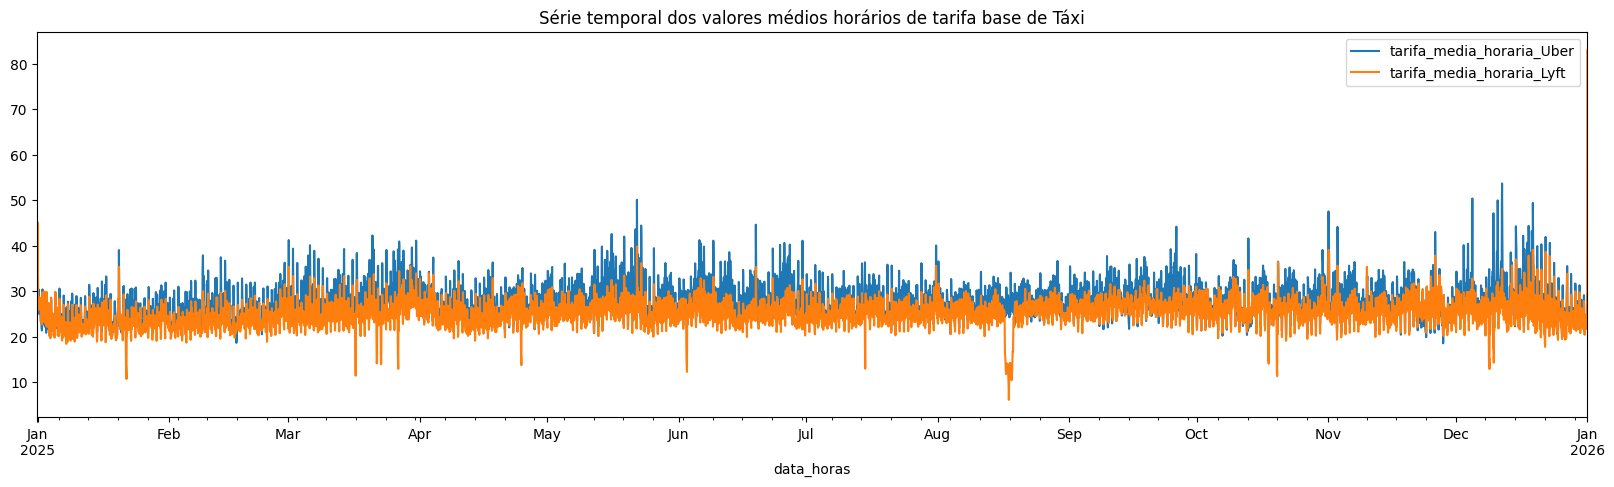

In [242]:
media_horaria.plot(figsize=(20, 5),
                   title='Série temporal dos valores médios horários de tarifa base de Táxi')

<Axes: xlabel='data_horas'>

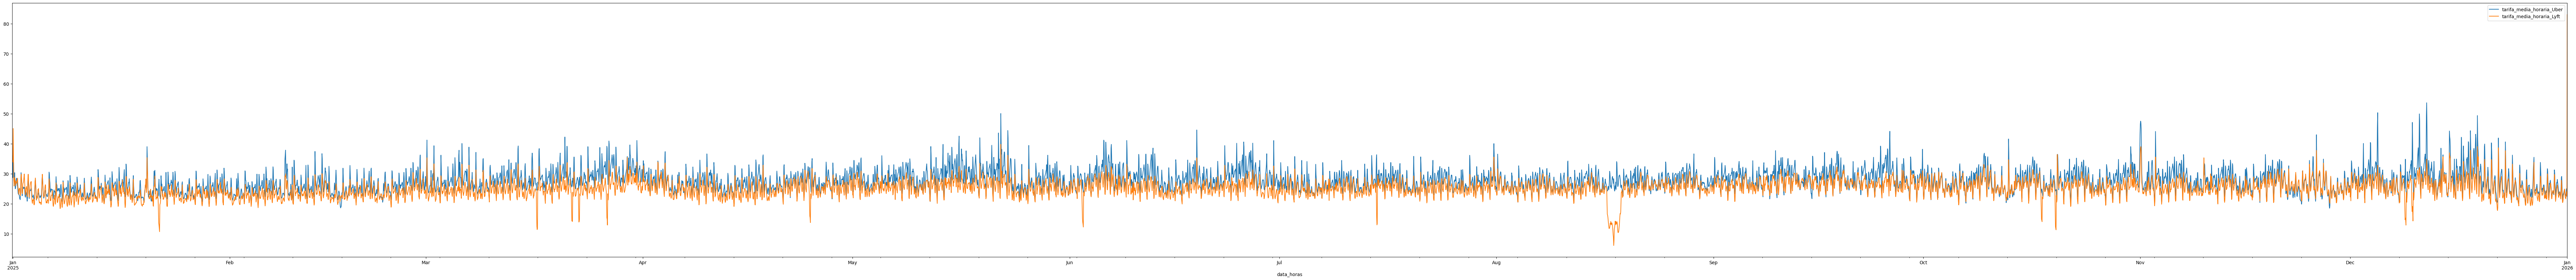

In [29]:
media_horaria.plot(figsize=(100, 10))

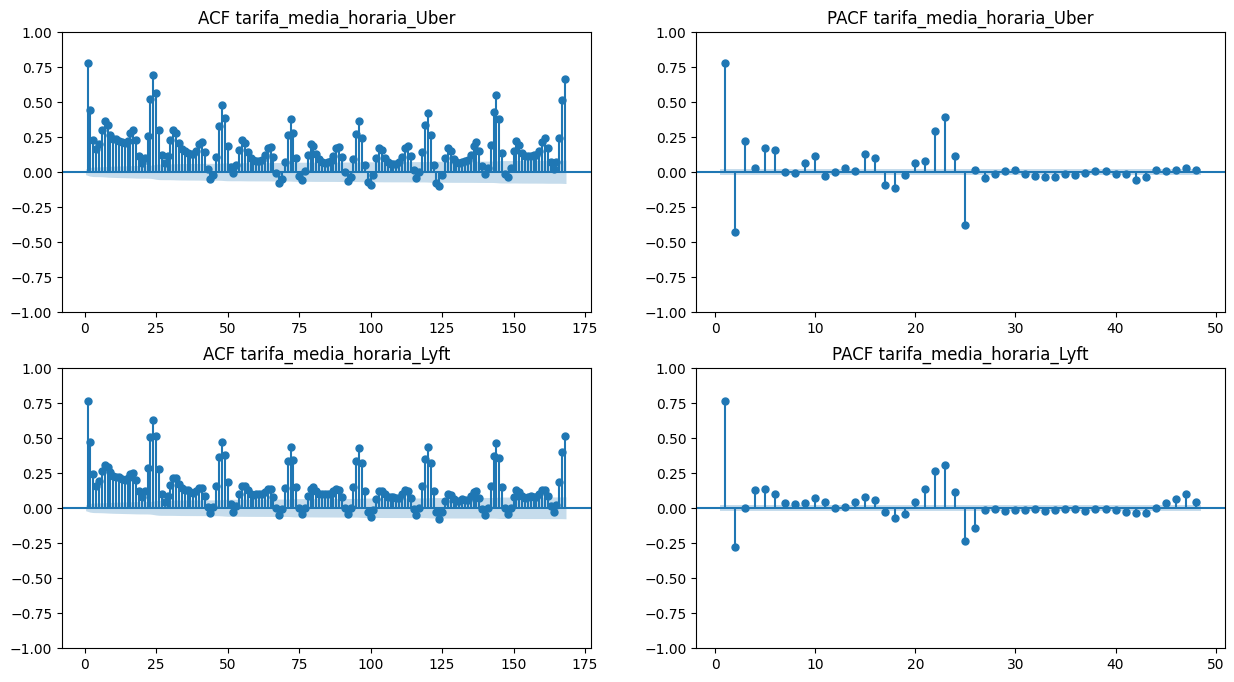

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize= (15, 8))

for i, serie_temp in enumerate(media_horaria.columns):
    plot_acf(media_horaria[serie_temp], lags = 168, alpha = 0.05, adjusted = False, zero = False, ax = axes[i, 0])
    axes[i,0].set_title(f'ACF {serie_temp}')
    plot_pacf(media_horaria[serie_temp], lags = 48, alpha = 0.05, method = 'ywm', zero = False, ax = axes[i, 1])
    axes[i,1].set_title(f'PACF {serie_temp}')

Conclusão ACF e PACF:

A ACF apresenta uma autocorrelação forte nos primeiros lags e decai lentamente, com picos repetidos em múltiplos de 24 horas, o que indica forte sazonalidade diária. O pico próximo de 168 horas sugere também a presença de um efeito semanal. Já a PACF mostra dependência forte nos primeiros lags, com um segundo grande pico negativo, o que aponta para uma dinâmica de compensação ou reversão de curto prazo (um valor alto da tarifa tende a estar associado a um valor mais baixo duas horas depois e vice-versa, após controlar os efeitos dos lags intermediários). Além disso, há um pico sazonal por volta de 24 horas, indicando que a tarifa depende tanto dos valores recentes quanto do ciclo diário. Após o lag 24, as autocorrelações parciais tornam-se próximas de zero, sugerindo que a maior parte da dependência temporal direta é explicada pelas últimas 24 horas.

# Validação de Estacionariedade: Testes de Hipóteses Estatísticas (ADF e KPSS)

A premissa de **estacionariedade** é o pilar que garante que as inferências estatísticas e as previsões futuras sejam válidas. Modelar uma série não estacionária sem os devidos ajustes resulta em regressões espúrias (falsas correlações causadas apenas por tendências compartilhadas).

Para mitigar esse risco de forma metodológica, a literatura estatística recomenda uma abordagem confirmatória cruzada combinando dois testes clássicos com hipóteses inversas: o **Teste de Dickey-Fuller Aumentado (ADF)** e o **Teste KPSS**.

---

## 1. Teste de Dickey-Fuller Aumentado (ADF)

O teste ADF é um teste de **Raiz Unitária**. Sua função primordial é determinar se uma série temporal possui uma tendência estocástica que a torna não estacionária, avaliando se o comportamento passado da série tem uma força de atração permanente ou se os choques na série se dissipam ao longo do tempo.

### 1.1 Definição Estatística e Matemática

O teste baseia-se em um modelo autorregressivo linear onde a primeira diferença da série, $\Delta Y_t$, é regredida contra o seu valor defasado no tempo anterior ($Y_{t-1}$) e termos de diferenças defasadas para remover a autocorrelação dos resíduos. A equação estrutural do ADF é expressa como:

$$\Delta Y_t = \alpha + \beta t + \gamma Y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta Y_{t-i} + \varepsilon_t$$

Onde:

* $\Delta Y_t = Y_t - Y_{t-1}$ é a primeira diferença da série no tempo $t$.
* $\alpha$ é o termo de intercepto (constante/drift).
* $\beta t$ é uma tendência determinística temporal.
* $\gamma$ é o coeficiente crítico testado. Se $\gamma = 0$, a série possui uma raiz unitária.
* $p$ é o número de defasagens estruturais inseridas para garantir que o termo de erro $\varepsilon_t$ seja um ruído branco.

As hipóteses formais do teste são formuladas da seguinte maneira:

* **Hipótese Nula ($H_0$):** $\gamma = 0$. A série possui raiz unitária (é **não estacionária**).
* **Hipótese Alternativa ($H_1$):** $\gamma < 0$. A série não possui raiz unitária (é **estacionária**).

O teste calcula a estatística de teste (uma estatística t modificada para a distribuição de Dickey-Fuller) e a compara com os valores críticos tabelados.

### 1.2 Funcionamento Computacional e Parâmetros no `statsmodels`

No ecossistema Python, o teste é executado por meio da função `statsmodels.tsa.stattools.adfuller`. O método estima a equação de regressão por Mínimos Quadrados Ordinários (OLS) e calcula a significância assintótica do coeficiente de cauda.

```python
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(x, maxlag=None, regression='c', autolag='AIC')

```

* **`x` (array_like):** A série temporal unidimensional a ser testada (ex: volume de corridas por hora em Manhattan).
* **`maxlag` (int, opcional):** O número máximo de lags incluídos na soma das diferenças ($\sum \delta_i \Delta Y_{t-i}$). Se omitido, o algoritmo calcula um limite superior baseado na fórmula de Schwert: $12 \cdot (n/100)^{1/4}$.
* **`regression` (str, padrão='c'):** Define os componentes determinísticos incluídos na regressão:
* `'c'`: Inclui apenas a constante $\alpha$ (padrão para séries sem tendência linear explícita).
* `'ct'`: Inclui a constante $\alpha$ e a tendência linear $\beta t$ (essencial se os dados crescem de ano a ano).
* `'ctt'`: Inclui constante, tendência linear e tendência quadrática.
* `'n'`: Sem constante e sem tendência (assume média zero).


* **`autolag` (str, padrão='AIC'):** O critério de otimização computacional para escolher o número ideal de lags $p$. O algoritmo testa sequencialmente os lags e escolhe o que minimiza o critério especificado (`'AIC'` - Akaike Information Criterion, ou `'BIC'` - Bayesian Information Criterion).

### 1.3 Conclusões e Interpretação nos Dados TLC

A função retorna uma tupla contendo a estatística do teste, o p-valor e um dicionário com os valores críticos para 1%, 5% e 10%.

* **Se p-valor $\le \alpha$ (geralmente $0.05$):** Rejeita-se $H_0$. Conclui-se, com rigor estatístico, que a série **é estacionária**.
* **Se p-valor $> \alpha$:** Falha-se em rejeitar $H_0$. Conclui-se que a série **não é estacionária** (possui memória longa e variância infinita). Ao analisar o volume diário de táxis em Nova York, a presença de uma tendência de crescimento ou forte padrão semanal frequentemente fará o ADF falhar em rejeitar $H_0$, exigindo diferenciação.

---

## 2. Teste de Kwiatkowski-Phillips-Schmidt-Shin (KPSS)

O teste KPSS atua na direção oposta ao ADF. Ele foi desenhado como um teste complementar onde a hipótese nula assume a estacionariedade da série. Ele avalia se as flutuações de uma série temporal em torno de uma média estável ou de uma tendência determinística são estacionárias ou se seguem um passeio aleatório (*random walk*).

### 2.1 Definição Estatística e Matemática

O KPSS assume que a série temporal pode ser decomposta em uma tendência determinística, um passeio aleatório e um erro estacionário:

$$Y_t = \xi t + r_t + \varepsilon_t$$

Onde $\varepsilon_t$ é um erro estacionário e $r_t$ é o termo de passeio aleatório, definido por:

$$r_t = r_{t-1} + u_t$$

Aqui, $u_t$ é um ruído branco com média zero e variância $\sigma_u^2$. Se a variância do passeio aleatório for igual a zero ($\sigma_u^2 = 0$), então $r_t$ colapsa para uma constante fixa. Nesse cenário ideal, a série $Y_t$ torna-se dependente apenas da tendência determinística e do erro estacionário.

Portanto, as hipóteses estatísticas do KPSS são mapeadas como:

* **Hipótese Nula ($H_0$):** $\sigma_u^2 = 0$. A série é **estacionária** (estacionária em nível ou em torno de uma tendência).
* **Hipótese Alternativa ($H_1$):** $\sigma_u^2 > 0$. A série possui um passeio aleatório (é **não estacionária**).

A estatística de teste do Multiplicador de Lagrange (LM) é baseada na soma acumulada dos resíduos $S_t = \sum_{i=1}^{t} e_i$ obtidos da regressão de $Y_t$ contra os componentes determinísticos:

$$LM = \frac{\sum_{t=1}^{n} S_t^2}{n^2 \hat{\sigma}^2}$$

Onde $\hat{\sigma}^2$ é um estimador consistente da variância de longo prazo dos resíduos (frequentemente calculado via janelas de Newey-West).

### 2.2 Funcionamento Computacional e Parâmetros no `statsmodels`

No Python, o teste é invocado por `statsmodels.tsa.stattools.kpss`. Diferente do ADF, o cálculo envolve estimar matrizes de covariância robustas à heterocedasticidade e autocorrelação (HAC).

```python
from statsmodels.tsa.stattools import kpss

resultado_kpss = kpss(x, regression='c', nlags='auto')

```

* **`x` (array_like):** A série temporal sob análise.
* **`regression` (str, padrão='c'):**
* `'c'`: Assume que a série é estacionária em nível (ao redor de uma média constante).
* `'ct'`: Assume que a série é estacionária ao redor de uma tendência linear determinística (*trend-stationary*).


* **`nlags` (int ou str, padrão='auto'):** Define o tamanho da janela de lags para o estimador de variância de longo prazo Newey-West. O valor `'auto'` aplica o método de seleção automática de largura de banda de Andrews (1991), altamente recomendado para evitar distorções no poder do teste em amostras grandes como as do TLC.

### 2.3 Conclusões e Interpretação nos Dados TLC

A interpretação dos resultados exige atenção redobrada, pois os papéis de $H_0$ e $H_1$ estão invertidos em relação ao padrão usual:

* **Se p-valor $\le \alpha$ (ex: $0.05$):** Rejeita-se $H_0$. Conclui-se que a série **não é estacionária** (possui uma raiz unitária).
* **Se p-valor $> \alpha$:** Falha-se em rejeitar $H_0$. Conclui-se que a série **é estacionária**.

---

## 3. Análise Confirmatória Cruzada: Matriz de Decisão

Para conferir um padrão metodológico profissional e acadêmico ao seu relatório técnico, você não deve analisar o ADF e o KPSS de forma isolada. Junte os resultados de ambos em uma estrutura de validação cruzada para classificar a série de dados do TLC de acordo com a tabela abaixo:

| Caso | Teste ADF | Teste KPSS | Diagnóstico Estatístico | Ação de Engenharia de Dados Requerida |
| --- | --- | --- | --- | --- |
| **1** | Rejeita $H_0$ (Estacionária) | Não rejeita $H_0$ (Estacionária) | **Estacionariedade Forte** | A série está pronta para modelagem linear direta (ex: ARMA). |
| **2** | Não rejeita $H_0$ (Não Estac.) | Rejeita $H_0$ (Não Estac.) | **Não Estacionariedade Forte** | A série possui raiz unitária. Deve-se aplicar uma diferenciação ($\Delta Y_t$). |
| **3** | Não rejeita $H_0$ (Não Estac.) | Não rejeita $H_0$ (Estacionária) | **Série possui fraca potência de dados** | O sinal é inconclusivo ou a amostra é muito curta para capturar a dinâmica de longo prazo. |
| **4** | Rejeita $H_0$ (Estacionária) | Rejeita $H_0$ (Não Estac.) | **Estacionariedade em Torno da Tendência** | A série flutua de forma estável, mas ao redor de uma linha de tendência determinística clara. Deve-se remover a tendência (*detrending*) ou usar diferenciação para estabilizar a média. |

> **Nota Metodológica para os Dados do TLC NYC:** Em séries de demanda de transporte urbano, é extremamente comum encontrar o **Caso 4**. As corridas de táxi possuem ciclos determinísticos muito fortes (picos fixos comerciais e de finais de semana) misturados com crescimento estrutural da frota. O ADF pode identificar que a série retorna à sua tendência após choques (rejeitando $H_0$), enquanto o KPSS identifica que a variação de nível ao longo dos meses viola a média constante (rejeitando $H_0$). Identificar esse cenário evitará que você tire conclusões precipitadas em seu modelo preditivo.

---

## 4. Referências Bibliográficas

1. **DICKEY, David A.; FULLER, Wayne A.** *Distribution of the Estimators for Autoregressive Time Series with a Unit Root*. Journal of the American Statistical Association, v. 74, n. 366, p. 427-431, 1979.
2. **KWIATKOWSKI, Denis; PHILLIPS, Peter C. B.; SCHMIDT, Peter; SHIN, Yongcheol.** *Testing the null hypothesis of stationarity against the alternative of a unit root*. Journal of Econometrics, v. 54, n. 1-3, p. 159-178, 1992.
3. **HAMILTON, James D.** *Time Series Analysis*. Princeton University Press, 1994. (Referência matemática abrangente para as provas assintóticas de ambos os testes).

---

Como você está lidando com os dados de registros de corrida de Nova York (TLC), você pretende aplicar esses testes na série bruta ou já realizou algum tipo de agrupamento temporal (como contagem de corridas por hora ou por dia)?

In [39]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

adf_uber = adfuller(media_horaria['tarifa_media_horaria_Uber'], regression = 'c', autolag = 'AIC', maxlag = 24)
adf_lyft = adfuller(media_horaria['tarifa_media_horaria_Lyft'], regression = 'c', autolag = 'AIC', maxlag = 24)

kpss_uber = kpss(media_horaria['tarifa_media_horaria_Uber'], regression = 'c' , nlags = 'auto')
kpss_lyft = kpss(media_horaria['tarifa_media_horaria_Lyft'], regression = 'c', nlags = 'auto')

C:\Users\mayma\AppData\Local\Temp\ipykernel_2340\1915506782.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_uber = kpss(media_horaria['tarifa_media_horaria_Uber'], regression = 'c' , nlags = 'auto')
C:\Users\mayma\AppData\Local\Temp\ipykernel_2340\1915506782.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_lyft = kpss(media_horaria['tarifa_media_horaria_Lyft'], regression = 'c', nlags = 'auto')


In [41]:
print(f'adfuller Uber: {adf_uber}\nadfuller Lyft: {adf_lyft}\nkpss Uber {kpss_uber}\nkpss Lyft {kpss_lyft}')

adfuller Uber: (np.float64(-7.326352890309352), np.float64(1.1583030952593753e-10), 24, 8737, {'1%': np.float64(-3.431098680587732), '5%': np.float64(-2.861870867017309), '10%': np.float64(-2.5669461155438067)}, np.float64(31779.768312676282))
adfuller Lyft: (np.float64(-7.338424737045289), np.float64(1.0810818606383142e-10), 24, 8737, {'1%': np.float64(-3.431098680587732), '5%': np.float64(-2.861870867017309), '10%': np.float64(-2.5669461155438067)}, np.float64(30529.058513114105))
kpss Uber (np.float64(1.9216364145846387), np.float64(0.01), 46, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
kpss Lyft (np.float64(4.0183671231484865), np.float64(0.01), 45, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


O teste ADF rejeitou a hipótese nula de raiz unitária, enquanto o KPSS rejeitou a hipótese nula de estacionariedade. A combinação dos resultados sugere que a série em nível apresenta forte componente sazonal e não pode ser tratada como estacionária sem transformação.

A sazonalidade atrapalha na análise de estacionariedade porque ela cria padrões repetitivos que alteram as propriedades estatísticas como a média (há valores que sobem e descem em horários específicos, invalidando a média constante) e a variância (a dispersão dos dados pode ser muito maior nos horários de pico do que nos horários de baixa demanda).

Portanto, para contornar o problema de sazonalidade, será aplicada a técnica de diferenciação sazonal múltipla. Primeiramente, subtraindo o valor da observação atual pelo valor do mesmo horário no dia anterior e, em seguida, aplicando a diferença em relação à semana anterior (isso porque foram observadas sazonalidades diárias e semanais pelas análises ACF e PACF).

Antes foi testado nos testes adfuller e kpss, se os valores médios horários da tarifa base eram estacionários; agora será testado se as variações (diárias e semanais) dessas tarifas são estacionárias ou não.

In [60]:
dif24_tarifa_Uber = media_horaria['tarifa_media_horaria_Uber'].diff(24).dropna()
dif24_tarifa_Lyft = media_horaria['tarifa_media_horaria_Lyft'].diff(24).dropna()

dif24_adf_uber = adfuller(dif24_tarifa_Uber, regression = 'c', autolag = 'AIC', maxlag = 24)
dif24_adf_lyft = adfuller(dif24_tarifa_Lyft, regression = 'c', autolag = 'AIC', maxlag = 24)

dif24_kpss_uber = kpss(dif24_tarifa_Uber, regression = 'c' , nlags = 'auto')
dif24_kpss_lyft = kpss(dif24_tarifa_Lyft, regression = 'c', nlags = 'auto')

C:\Users\mayma\AppData\Local\Temp\ipykernel_2340\1300730262.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  dif24_kpss_uber = kpss(dif24_tarifa_Uber, regression = 'c' , nlags = 'auto')
C:\Users\mayma\AppData\Local\Temp\ipykernel_2340\1300730262.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  dif24_kpss_lyft = kpss(dif24_tarifa_Lyft, regression = 'c', nlags = 'auto')


In [61]:
print(f'Teste adfuller com diferenciação sazonal de 1 dia - Uber:\n {dif24_adf_uber}\n\nTeste adfuller com diferenciação sazonal de 1 dia - Lyft:\n {dif24_adf_lyft}\n\nTeste KPSS com diferenciação sazonal de 1 dia - Uber:\n {dif24_kpss_uber}\n\nTeste KPSS com diferenciação sazonal de 1 dia - Lyft:\n {dif24_kpss_lyft}')

Teste adfuller com diferenciação sazonal de 1 dia - Uber:
 (np.float64(-15.551106788095419), np.float64(2.099493544670287e-28), 24, 8713, {'1%': np.float64(-3.431100743440016), '5%': np.float64(-2.8618717785456185), '10%': np.float64(-2.566946600756551)}, np.float64(33249.91688441713))

Teste adfuller com diferenciação sazonal de 1 dia - Lyft:
 (np.float64(-16.0865647095284), np.float64(5.308567539355167e-29), 24, 8713, {'1%': np.float64(-3.431100743440016), '5%': np.float64(-2.8618717785456185), '10%': np.float64(-2.566946600756551)}, np.float64(31576.139749879057))

Teste KPSS com diferenciação sazonal de 1 dia - Uber:
 (np.float64(0.010764356932988437), np.float64(0.1), 44, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

Teste KPSS com diferenciação sazonal de 1 dia - Lyft:
 (np.float64(0.01396159545120463), np.float64(0.1), 45, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


In [62]:
dif168_adf_uber = adfuller(media_horaria['tarifa_media_horaria_Uber'].diff(168).dropna(), regression = 'c', autolag = 'AIC', maxlag = 24)
dif168_adf_lyft = adfuller(media_horaria['tarifa_media_horaria_Lyft'].diff(168).dropna(), regression = 'c', autolag = 'AIC', maxlag = 24)

dif168_kpss_uber = kpss(media_horaria['tarifa_media_horaria_Uber'].diff(168).dropna(), regression = 'c' , nlags = 'auto')
dif168_kpss_lyft = kpss(media_horaria['tarifa_media_horaria_Lyft'].diff(168).dropna(), regression = 'c', nlags = 'auto')

C:\Users\mayma\AppData\Local\Temp\ipykernel_2340\905133776.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  dif168_kpss_uber = kpss(media_horaria['tarifa_media_horaria_Uber'].diff(168).dropna(), regression = 'c' , nlags = 'auto')
C:\Users\mayma\AppData\Local\Temp\ipykernel_2340\905133776.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  dif168_kpss_lyft = kpss(media_horaria['tarifa_media_horaria_Lyft'].diff(168).dropna(), regression = 'c', nlags = 'auto')


In [64]:
print(f'Teste adfuller com diferenciação sazonal de 1 semana - Uber:\n {dif168_adf_uber}\n\nTeste adfuller com diferenciação sazonal de 1 semana - Lyft:\n {dif168_adf_lyft}\n\nTeste KPSS com diferenciação sazonal de 1 semana - Uber:\n {dif168_kpss_uber}\n\nTeste KPSS com diferenciação sazonal de 1 semana - Lyft:\n {dif168_kpss_lyft}')

Teste adfuller com diferenciação sazonal de 1 semana - Uber:
 (np.float64(-7.6410377988335165), np.float64(1.8956747506311703e-11), 24, 8569, {'1%': np.float64(-3.4311133632866704), '5%': np.float64(-2.861877354959968), '10%': np.float64(-2.566949569122365)}, np.float64(31788.594782628737))

Teste adfuller com diferenciação sazonal de 1 semana - Lyft:
 (np.float64(-8.902191088992806), np.float64(1.1632754273440711e-14), 24, 8569, {'1%': np.float64(-3.4311133632866704), '5%': np.float64(-2.861877354959968), '10%': np.float64(-2.566949569122365)}, np.float64(32191.272965960576))

Teste KPSS com diferenciação sazonal de 1 semana - Uber:
 (np.float64(0.21266115972260846), np.float64(0.1), 48, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

Teste KPSS com diferenciação sazonal de 1 semana - Lyft:
 (np.float64(0.0662311847056991), np.float64(0.1), 49, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


### Conclusão dos testes ADF e KPSS:

Os testes ADF e KPSS apresentaram resultados conflitantes para as séries originais, sugerindo a presença de componentes sazonais. Após a aplicação de diferenciação sazonal diária (24 horas) e semanal (168 horas), ambos os testes passaram a indicar estacionariedade. A diferenciação diária mostrou-se particularmente eficaz, produzindo estatísticas KPSS mais próximas de zero. Esses resultados indicam que a principal fonte de não estacionariedade observada inicialmente estava associada à sazonalidade diária das tarifas médias horárias dos aplicativos de transporte.

In [52]:
media_horaria['tarifa_media_horaria_Uber'].diff(24).dropna()

data_horas
2025-01-01 23:00:00    -6.887556
2025-01-02 00:00:00    -7.316697
2025-01-02 01:00:00   -18.209236
2025-01-02 02:00:00   -12.066716
2025-01-02 03:00:00    -0.680999
                         ...    
2025-12-31 20:00:00    -0.202151
2025-12-31 21:00:00     1.028177
2025-12-31 22:00:00     1.375470
2025-12-31 23:00:00    -0.358272
2026-01-01 00:00:00     5.946934
Name: tarifa_media_horaria_Uber, Length: 8738, dtype: float64

In [51]:
media_diaria = con.sql("""
SELECT DATE(request_datetime) AS dias, 
    AVG(base_passenger_fare) FILTER (WHERE hvfhs_license_num = 'HV0003') AS tarifa_media_diaria_Uber,
    AVG(base_passenger_fare) FILTER (WHERE hvfhs_license_num = 'HV0005') AS tarifa_media_diaria_Lyft
FROM fhvhv_2025 GROUP BY DATE(request_datetime) ORDER BY dias ASC;
""").df()

media_diaria

,dias,tarifa_media_diaria_Uber,tarifa_media_diaria_Lyft
0,2024-12-31,28.718719,34.032045
1,2025-01-01,28.293132,29.153675
2,2025-01-02,24.283964,25.904710
3,2025-01-03,23.483072,23.576163
4,2025-01-04,22.839212,22.076921
...,...,...,...
362,2025-12-28,25.126578,23.537892
363,2025-12-29,25.169060,23.953874
364,2025-12-30,25.228352,23.863812
365,2025-12-31,23.778803,22.927155


<Axes: title={'center': 'Série temporal dos valores médios diários de tarifa base de Uber e Lyft'}, xlabel='dias'>

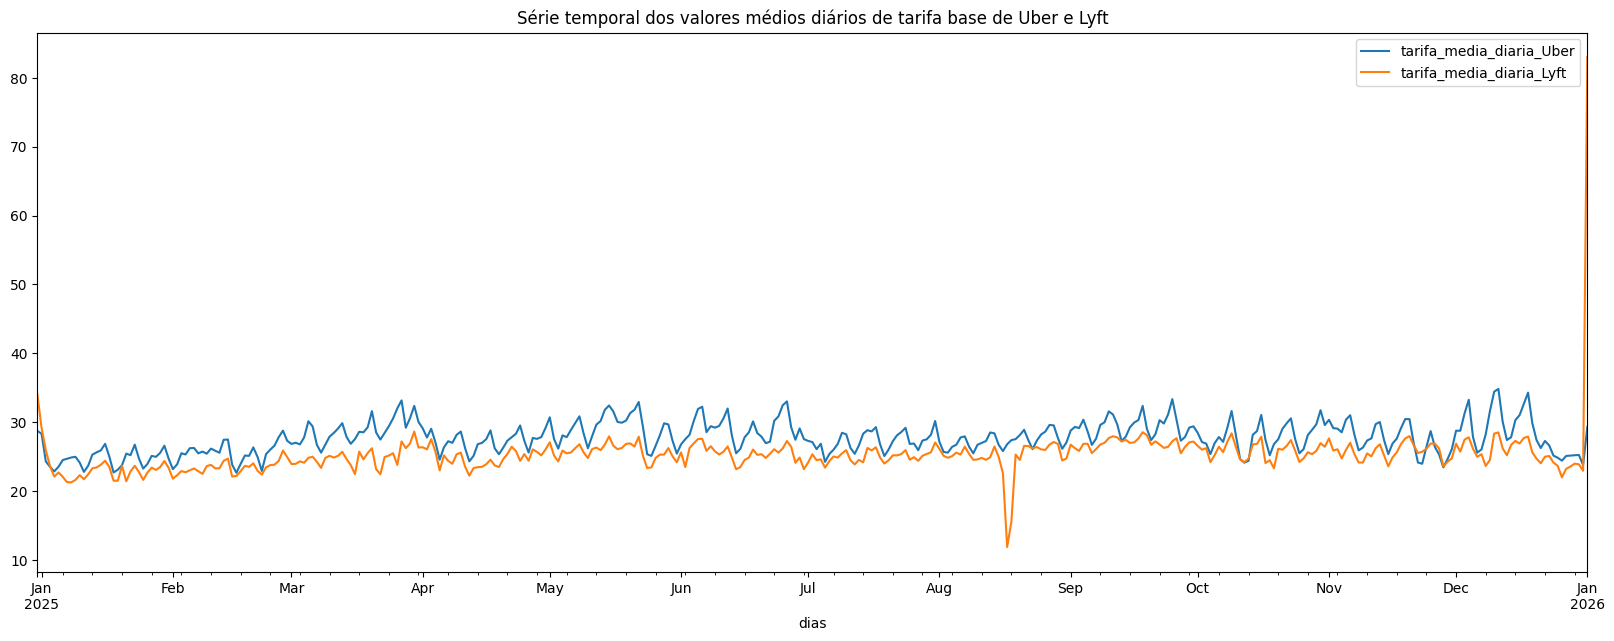

In [52]:
media_diaria.set_index('dias', inplace = True)

media_diaria.plot(figsize=(20, 7),
                  title='Série temporal dos valores médios diários de tarifa base de Uber e Lyft')

In [ ]:
media_diaria

,tarifa_media_diaria_Uber,tarifa_media_diaria_Lyft
dias,,
2024-12-31,28.718719,34.032045
2025-01-01,28.293132,29.153675
2025-01-02,24.283964,25.904710
2025-01-03,23.483072,23.576163
2025-01-04,22.839212,22.076921
...,...,...
2025-12-28,25.126578,23.537892
2025-12-29,25.169060,23.953874
2025-12-30,25.228352,23.863812


# Modelagem Preditiva Avançada: O Modelo SARIMAX

Na econometria clássica e na ciência de dados aplicada a sistemas complexos, prever o comportamento futuro exige algoritmos que capturem múltiplos horizontes de dependência. O modelo **SARIMAX** (*Seasonal Autoregressive Integrated Moving Average with Exogenous Regressors*) representa o estado da arte das metodologias lineares paramétricas de espaço de estados, permitindo modelar séries com tendência, ciclos sazonais e influências externas simultaneamente.

---

## 1. Definição Estatística e Matemática

O SARIMAX expande a metodologia clássica de Box-Jenkins (ARIMA) ao incorporar duas frentes fundamentais: a modelagem multiplicativa da **sazonalidade** e a inclusão de **variáveis exógenas** ($\mathbf{X}$). 

Diferente de uma simples regressão linear, o SARIMAX implementado em bibliotecas modernas opera sob a arquitetura de **Regressão com Erros SARIMA**. Isso significa que o modelo estima os impactos das variáveis exógenas e, simultaneamente, modela o resíduo (o erro) que possui autocorrelação temporal.

A formulação matemática geral é expressa pelo seguinte sistema de equações:

$$Y_t = \mathbf{X}_t \boldsymbol{\beta} + u_t$$

Onde $Y_t$ é a variável dependente no tempo $t$, $\mathbf{X}_t$ é o vetor de variáveis exógenas, $\boldsymbol{\beta}$ é o vetor de coeficientes a serem estimados e $u_t$ é o termo de erro estocástico autocorrelacionado. O comportamento desse erro $u_t$ é regido pelo processo polinomial SARIMA $(p,d,q) \times (P,D,Q)_s$:

$$\phi_p(B) \Phi_P(B^s) (1-B)^d (1-B^s)^D u_t = \theta_q(B) \Theta_Q(B^s) \varepsilon_t$$

Onde:
* **$B$ (Operador de Defasagem / *Backshift*):** Definido matematicamente como $B^k X_t = X_{t-k}$.
* **$(1-B)^d$ e $(1-B^s)^D$:** Operadores de diferenciação simples (ordem $d$) e diferenciação sazonal (ordem $D$ para um período $s$), utilizados para estabilizar a média da série.
* **$\phi_p(B)$ e $\theta_q(B)$:** Polinômios autorregressivo (AR) e de média móvel (MA) da parte não sazonal, de ordens $p$ e $q$:
  $$\phi_p(B) = 1 - \phi_1 B - \phi_2 B^2 - \dots - \phi_p B^p$$
  $$\theta_q(B) = 1 + \theta_1 B + \theta_2 B^2 + \dots + \theta_q B^q$$
* **$\Phi_P(B^s)$ e $\Theta_Q(B^s)$:** Polinômios autorregressivo sazonal (SAR) e de média móvel sazonal (SMA), de ordens $P$ e $Q$:
  $$\Phi_P(B^s) = 1 - \Phi_1 B^s - \Phi_2 B^{2s} - \dots - \Phi_P B^{Ps}$$
  $$\Theta_Q(B^s) = 1 + \Theta_1 B^s + \Theta_2 B^{2s} + \dots + \Theta_Q B^{Qs}$$
* **$\varepsilon_t$:** Um processo de Ruído Branco com média zero e variância constante $\sigma^2$.

---

## 2. Casos de Uso Ideais

O SARIMAX é a escolha metodológica ideal quando os dados apresentam as seguintes características estruturais:

* **Sazonalidade Multiplicativa Definida:** Séries temporais em que os padrões cíclicos se repetem de forma rígida em períodos conhecidos ($s$). Nos dados do TLC NYC, isso se manifesta na sazonalidade diária ($s=24$ se o dado for horário) ou semanal ($s=7$ se o dado for diário).
* **Existência de Drivers Externos Conhecidos:** Quando o fenômeno sob análise sofre impactos de variáveis ambientais ou macroeconômicas.
* **Requisito de Rigor Estatístico e Inferência:** Casos acadêmicos ou profissionais onde não basta apenas prever o ponto futuro, mas é obrigatório extrair intervalos de confiança matemáticos estritos e entender a significância p-valor de cada variável explicativa.

---

## 3. Prós e Contras do Modelo

Para fins de justificativa metodológica em relatórios e dissertações, o balanço analítico do modelo compreende:

### Vantagens (Prós)
* **Alta Interpretabilidade:** Ao contrário de modelos de caixa-preta (*Deep Learning*), os coeficientes $\boldsymbol{\beta}$ das variáveis exógenas e os parâmetros $\phi, \theta$ possuem significado físico e econômico direto (ex: elasticidade da demanda por variação de temperatura).
* **Consistência Estatística:** Por ser baseado em formulações de Espaço de Estados (estimado via Filtro de Kalman), o modelo calcula de maneira ótima a incerteza futura, gerando bandas de confiança estatisticamente confiáveis.
* **Flexibilidade Estrutural:** Combina em um único ecossistema matemático a correção de não-estacionariedade (integração), a autocorrelação de curto prazo e os efeitos cíclicos de longo prazo.

### Desvantagens (Contras)
* **Alto Custo Computacional em Lags Longos:** A estimação dos parâmetros via Máxima Verossimilhança com o Filtro de Kalman exige inversões matriciais consecutivas. Se o período sazonal $s$ for muito grande (ex: dados horários com sazonalidade semanal, onde $s=168$), o modelo pode falhar por esgotamento de memória ou levar horas para convergir.
* **Inabilidade de Capturar Não-Linearidades Complexas:** Sendo um modelo intrinsecamente linear, o SARIMAX falha se a dinâmica de interação entre as variáveis exógenas e a série de tempo for fortemente não-linear.
* **Sensibilidade à Parametrização:** A escolha dos hiperparâmetros $(p,d,q) \times (P,D,Q)_s$ exige uma busca em grade (*Grid Search*) computacionalmente exaustiva guiada por critérios como AIC/BIC, dada a ausência de uma heurística direta de otimização global.

---

## 4. Funcionamento Computacional e Parâmetros no `statsmodels`

No ecossistema Python, o modelo é implementado via classe de espaço de estados `statsmodels.tsa.statespace.sarimax.SARIMAX`. Internamente, o algoritmo transforma a equação em uma representação de transição de estados e maximiza a função de verossimilhança por meio de algoritmos de otimização numérica (como o BFGS).

```python
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo = SARIMAX(
    endog=sere_demanda, 
    exog=matriz_exogenas, 
    order=(1, 1, 1), 
    seasonal_order=(1, 0, 1, 24),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado = modelo.fit(disp=False)

```

### Detalhamento dos Parâmetros Críticos

* **`endog` (array_like):** A variável dependente e endógena da série temporal (ex: a série tratada de contagem de viagens do TLC).
* **`exog` (array_like, opcional):** Matriz contendo as covariáveis exógenas alinhadas temporalmente com a série principal. Devem estar limpas e sem dados ausentes.
* **`order` (tuple):** A tripla $(p, d, q)$ correspondente à parte não sazonal. O valor de $d$ deve ser obtido diretamente com base nos resultados prévios dos testes ADF e KPSS.
* **`seasonal_order` (tuple):** A quádrupla $(P, D, Q, s)$ para a dinâmica sazonal. O parâmetro $s$ define o comprimento do ciclo (ex: $s=24$ para dados horários com ciclo diário).
* **`trend` (str, opcional):** Controla o polinômio de tendência determinística ($\alpha$). Pode ser `'c'` (inclui constante/drift), `'t'` (inclui tendência temporal linear), `'ct'` ou `'n'` (sem tendência).
* **`enforce_stationarity` (bool, padrão=True):** Se mantido como `True`, o otimizador restringe os coeficientes autorregressivos para garantir que fiquem dentro do círculo unitário (estacionariedade). Em séries complexas com dados reais massivos, mudar para `False` pode acelerar a convergência numérica sem comprometer gravemente a estabilidade local.
* **`enforce_invertibility` (bool, padrão=True):** Força os coeficientes de média móvel (MA) a garantirem a propriedade de invertibilidade do processo.

---



In [82]:
import pandas as pd

df = media_horaria[['tarifa_media_horaria_Uber']].rename(
    columns={'tarifa_media_horaria_Uber': 'y'}
).copy()

df = df.asfreq('h')              # garante frequência horária regular
df['y'] = df['y'].interpolate('time')  # preenche lacunas pequenas

In [68]:
media_horaria

,tarifa_media_horaria_Uber,tarifa_media_horaria_Lyft
data_horas,,
2024-12-31 23:00:00,28.710141,34.032045
2025-01-01 00:00:00,29.013556,33.934999
2025-01-01 01:00:00,39.608897,45.095354
2025-01-01 02:00:00,34.754015,36.725979
2025-01-01 03:00:00,27.629214,27.886079
...,...,...
2025-12-31 20:00:00,23.309782,22.594040
2025-12-31 21:00:00,25.028670,24.021711
2025-12-31 22:00:00,24.901682,23.738568


In [67]:
df

,y
data_horas,
2024-12-31 23:00:00,28.710141
2025-01-01 00:00:00,29.013556
2025-01-01 01:00:00,39.608897
2025-01-01 02:00:00,34.754015
2025-01-01 03:00:00,27.629214
...,...
2025-12-31 20:00:00,23.309782
2025-12-31 21:00:00,25.028670
2025-12-31 22:00:00,24.901682


In [83]:
def make_features(idx):
    X = pd.DataFrame(index=idx)
    X['hour'] = idx.hour
    X['dow'] = idx.dayofweek
    X['month'] = idx.month
    X['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    return pd.get_dummies(X, columns=['hour', 'dow', 'month'], drop_first=True, dtype = int)

X = make_features(df.index)
y = df['y']

In [84]:
y

data_horas
2024-12-31 23:00:00    28.710141
2025-01-01 00:00:00    29.013556
2025-01-01 01:00:00    39.608897
2025-01-01 02:00:00    34.754015
2025-01-01 03:00:00    27.629214
                         ...    
2025-12-31 20:00:00    23.309782
2025-12-31 21:00:00    25.028670
2025-12-31 22:00:00    24.901682
2025-12-31 23:00:00    22.531798
2026-01-01 00:00:00    29.307778
Freq: h, Name: y, Length: 8762, dtype: float64

In [85]:
X

,is_weekend,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
data_horas,,,,,,,,,,,,,,,,,,,,,
2024-12-31 23:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2025-01-01 00:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-01 01:00:00,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-01 02:00:00,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-01 03:00:00,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 20:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2025-12-31 21:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2025-12-31 22:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [86]:
test_size = 24 * 30   # último mês
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]

In [87]:
X_train

,is_weekend,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
data_horas,,,,,,,,,,,,,,,,,,,,,
2024-12-31 23:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2025-01-01 00:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-01 01:00:00,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-01 02:00:00,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-01-01 03:00:00,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01 20:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2025-12-01 21:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2025-12-01 22:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [88]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24),  # sazonalidade diária
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)
pred = res.get_forecast(steps=len(y_test), exog=X_test).predicted_mean

c:\Users\mayma\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(mae, rmse)

3.1420136770691656 4.341067250795942


In [90]:
future_steps = 24 * 30   # 1 mês
future_index = pd.date_range(
    start=df.index.max() + pd.Timedelta(hours=1),
    periods=future_steps,
    freq='h'
)

X_future = make_features(future_index)

final_res = model.fit(disp=False)
forecast = final_res.get_forecast(steps=future_steps, exog=X_future).predicted_mean

c:\Users\mayma\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ValueError: Provided exogenous values are not of the appropriate shape. Required (720, 41), got (720, 30).

In [ ]:
con.close()

NameError: name 'con' is not defined